#obtaining data



In [ ]:
import tensorflow as tf

text_file=tf.keras.utils.get_file(
    fname='fra-eng.zip',
    origin='http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip',
    extract=True
)

In [ ]:
import pathlib
text_file = pathlib.Path('/root/.keras/datasets/fra-eng_extracted/fra.txt')



In [ ]:
print(text_file)

In [ ]:
with open(text_file) as fp:
  text_pairs=[line for line in fp]

In [ ]:
import random
print(random.choice(text_pairs))


In [ ]:
def normalize(line):
    import unicodedata
    import re

    line = unicodedata.normalize("NFKC", line.strip().lower())

    line = re.sub(r"^([^\w\s])(?!\s)", r"\1 ", line)
    line = re.sub(r"(?!\s)([^\w\s])$", r" \1", line)

    eng, fre = line.split("\t")
    fre = f"[start] {fre} [end]"

    return eng, fre


In [ ]:
with open(text_file, encoding='utf-8') as fp:
    text_pair = [normalize(line) for line in fp if "\t" in line]


In [ ]:
print(random.choice(text_pair))


In [ ]:
eng_token_set, fre_token_set = set(), set()
eng_maxlen, fre_maxlen = 0, 0

for eng, fre in text_pair:
    eng_words = eng.split()
    fre_words = fre.split()

    eng_maxlen = max(eng_maxlen, len(eng_words))
    fre_maxlen = max(fre_maxlen, len(fre_words))

    eng_token_set.update(eng_words)
    fre_token_set.update(fre_words)

print(f"Total tokens in English: {len(eng_token_set)}")
print(f"Total tokens in French: {len(fre_token_set)}")
print(f"Max length of English sentence: {eng_maxlen}")
print(f"Max length of French sentence: {fre_maxlen}")


In [ ]:
import pickle
with open('eng_token_set.pickle', 'wb') as fp:
    pickle.dump(eng_token_set, fp)



In [ ]:
from tensorflow.keras.layers import TextVectorization

import pickle
with open('/root/.keras/datasets/fra-eng_extracted/fra.txt', encoding='utf-8') as fp:
    text_pair = [normalize(line) for line in fp if "\t" in line]


In [ ]:
text_pair = list(text_pair)
random.shuffle(text_pair)


In [ ]:
import random
random.shuffle(text_pair)

n_val = int(0.15 * len(text_pair))
n_train = len(text_pair) - 2 * n_val

train_pair = text_pair[:n_train]
val_pair = text_pair[n_train:n_train + n_val]
test_pair = text_pair[n_train + n_val:]


In [ ]:
vocab_en=10690
vocab_fr=20069
seq_length=15

In [ ]:
eng_vect=TextVectorization(
    max_tokens=vocab_en,
    standardize=None,
    split='whitespace',
    output_mode='int',
    output_sequence_length=seq_length
)


In [ ]:
fre_vect=TextVectorization(
    max_tokens=vocab_fr,
    standardize=None,
    split='whitespace',
    output_mode='int',
    output_sequence_length=seq_length
)


In [ ]:
print(type(train_pair[0]))
print(train_pair[0])


In [ ]:
train_eng = [pair[0] for pair in train_pair]
train_fre = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng)
fre_vect.adapt(train_fre)


In [ ]:
eng_vect.adapt(train_eng)
fre_vect.adapt(train_fre)

In [ ]:

with open('vectorize.pickle', 'wb') as fp:
    data = {
        'train': train_pair,
        'test': test_pair,
        'eng_vect': eng_vect.get_config(),
        'fre_vect': fre_vect.get_config(),
        'eng_weights': eng_vect.get_weights(),
        'fre_weights': fre_vect.get_weights()
    }
    pickle.dump(data, fp)


In [ ]:
with open("vectorize.pickle", "rb") as fp:
    data = pickle.load(fp)

#embedding layer

In [99]:
from tensorflow.keras.layers import TextVectorization
import pickle

with open('vectorize.pickle', 'rb') as fp:
    data = pickle.load(fp)

# Recreate and restore English vectorizer
eng_vect = TextVectorization.from_config(data['eng_vect'])
eng_vect.set_weights(data['eng_weights'])

# Recreate and restore French vectorizer
fre_vect = TextVectorization.from_config(data['fre_vect'])
fre_vect.set_weights(data['fre_weights'])


In [100]:
import tensorflow as tf

# Format function: prepare source and target
def format_dataset(eng, fre):
    eng = eng_vect(eng)
    fre = fre_vect(fre)

    source = {
        'encode_inp': eng,
        'decode_inp': fre[:, :-1]  # decoder input (without [end])
    }

    target = fre[:, 1:]  # decoder target (without [start])
    return source, target

# Dataset creation function
def make_dataset(pairs, batch_size=64):
    eng_text, fre_text = zip(*pairs)  # unzip list of (eng, fre) pairs

    # Create TensorFlow dataset from text pairs
    dataset = tf.data.Dataset.from_tensor_slices((list(eng_text), list(fre_text)))

    # Shuffle, batch, format, and prefetch
    dataset = (
        dataset
        .shuffle(2048)
        .batch(batch_size)
        .map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
        .cache()
    )
    return dataset


In [101]:
train_ds = make_dataset(train_pair)
val_ds = make_dataset(val_pair)


In [102]:
import tensorflow as tf
import zipfile
import os
import pathlib

# 1. Download the dataset ZIP file
path_to_zip = tf.keras.utils.get_file(
    "fra-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip",
    extract=False  # <- do NOT auto-extract
)

# 2. Manually extract the zip file
extract_path = os.path.splitext(path_to_zip)[0]  # remove ".zip"
with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(path=pathlib.Path(path_to_zip).parent)

# 3. Now access the file safely
text_file = pathlib.Path(path_to_zip).parent / "fra.txt"

# Confirm file exists
print(f"Found dataset at: {text_file}")


Found dataset at: /root/.keras/datasets/fra.txt


In [103]:
def normalize(line):
    import unicodedata, re

    parts = line.strip().split("\t")
    if len(parts) != 2:
        return None  # skip malformed lines
    eng, fre = parts

    # Normalize and clean
    eng = unicodedata.normalize("NFKC", eng.lower())
    fre = unicodedata.normalize("NFKC", fre.lower())

    eng = re.sub(r"([?.!,¿])", r" \1 ", eng)
    fre = re.sub(r"([?.!,¿])", r" \1 ", fre)

    eng = re.sub(r"[^a-zA-Z?.!,¿]+", " ", eng).strip()
    fre = re.sub(r"[^a-zA-Z?.!,¿]+", " ", fre).strip()

    fre = "[start] " + fre + " [end]"
    return eng, fre


In [104]:
with open("/root/.keras/datasets/fra.txt", encoding='utf-8') as f:
    text_pairs = [normalize(line) for line in f]

# Remove any None values from lines that failed to split
text_pairs = [pair for pair in text_pairs if pair is not None]
import random

random.shuffle(text_pairs)

n_val = int(0.15 * len(text_pairs))
n_train = len(text_pairs) - 2 * n_val

train_pair = text_pairs[:n_train]
val_pair = text_pairs[n_train:n_train + n_val]
test_pair = text_pairs[n_train + n_val:]


from tensorflow.keras.layers import TextVectorization

MAX_LEN = 25
VOCAB_SIZE = 10000

eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

train_eng = [pair[0] for pair in train_pair]
train_fre = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng)
fre_vect.adapt(train_fre)
def format_dataset(eng, fre):
    eng = eng_vect(eng)
    fre = fre_vect(fre)

    return {
        'encode_inp': eng,
        'decode_inp': fre[:, :-1]
    }, fre[:, 1:]

def make_dataset(pairs, batch_size=64):
    eng_text, fre_text = zip(*pairs)
    dataset = tf.data.Dataset.from_tensor_slices((list(eng_text), list(fre_text)))
    dataset = (
        dataset.shuffle(2048)
        .batch(batch_size)
        .map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataset
train_ds = make_dataset(train_pair)
val_ds = make_dataset(val_pair)




In [105]:
# 8. Test one batch
for inputs, target in train_ds.take(1):
    print("Encode Input Shape:", inputs['encode_inp'].shape)
    print("Encode Input Sample:", inputs['encode_inp'][0].numpy())
    print("Decode Input Shape:", inputs['decode_inp'].shape)
    print("Decode Input Sample:", inputs['decode_inp'][0].numpy())
    print("Target Shape:", target.shape)
    print("Target Sample:", target[0].numpy())


Encode Input Shape: (64, 25)
Encode Input Sample: [ 10  50  78  26 243  27   3   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0]
Decode Input Shape: (64, 24)
Decode Input Sample: [  3  21  62 207  65  27 115   5  39 617   2   0   0   0   0   0   0   0
   0   0   0   0   0   0]
Target Shape: (64, 24)
Target Sample: [ 21  62 207  65  27 115   5  39 617   2   0   0   0   0   0   0   0   0
   0   0   0   0   0   0]


#positional embedding

In [106]:
import numpy as np
import tensorflow as tf
def pos_enc_matrix(l,d,n=10000):
  assert d%2==0
  d2=d//2
  P=np.zeros((l,d))
  k=np.arange(l).reshape(-1,1)
  i=np.arange(d2).reshape(1,-1)

  denom=np.power(n,-i/d2)
  args=k*denom

  P[:,::2]=np.sin(args)
  P[:,1::2]=np.cos(args)
  return P


In [107]:
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim, mask_zero=True
        )
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=seq_length, output_dim=embed_dim
        )
        self.seq_length = seq_length # Store seq_length

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs)
        # Generate positions based on the actual sequence length of the input batch
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        position_embeddings = self.position_embeddings(positions)

        # Expand position_embeddings to match the batch size of embedded_tokens
        position_embeddings = tf.expand_dims(position_embeddings, axis=0)
        position_embeddings = tf.tile(position_embeddings, [tf.shape(inputs)[0], 1, 1])

        # Add positional embeddings and apply mask
        output = embedded_tokens + position_embeddings
        mask = self.compute_mask(inputs)
        if mask is not None:
            # Expand mask to match the embedding dimension for element-wise multiplication
            mask = tf.cast(tf.expand_dims(mask, axis=-1), dtype=output.dtype)
            output = output * mask

        print(f"Shape of embedded_tokens: {tf.shape(embedded_tokens)}")
        print(f"Shape of position_embeddings: {tf.shape(position_embeddings)}")
        print(f"Shape of output after masking: {tf.shape(output)}")


        return output

    def compute_mask(self, *args, **kwargs):
        return self.token_embeddings.compute_mask(*args, **kwargs)

    def get_config(self):
        config = super().get_config()
        config.update({
            'seq_length': self.seq_length,
            'vocab_size': self.token_embeddings.input_dim,
            'embed_dim': self.token_embeddings.output_dim
        })
        return config

In [108]:
vocab_en=10000
# vocab_fr=20000
seq_length=25


In [109]:
for inputs, target in train_ds.take(1):
    print(inputs['encode_inp'])

    embed_en = PositionalEmbedding(seq_length, vocab_en, embed_dim=512)
    en_emb = embed_en(inputs['encode_inp'])

    mask = embed_en.compute_mask(inputs['encode_inp'])
    print(mask)


tf.Tensor(
[[  43    3  465 ...    0    0    0]
 [   5  217 2663 ...    0    0    0]
 [   3   74    6 ...    0    0    0]
 ...
 [   2   45    4 ...    0    0    0]
 [  10  125   78 ...    0    0    0]
 [  67  258    7 ...    0    0    0]], shape=(64, 25), dtype=int64)
Shape of embedded_tokens: Tensor("Shape_2:0", shape=(3,), dtype=int32)
Shape of position_embeddings: Tensor("Shape_3:0", shape=(3,), dtype=int32)
Shape of output after masking: Tensor("Shape_4:0", shape=(3,), dtype=int32)
Shape of embedded_tokens: [ 64  25 512]
Shape of position_embeddings: [ 64  25 512]
Shape of output after masking: [ 64  25 512]
tf.Tensor(
[[ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 ...
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]], shape=(64, 25), dtype=bool)


#neural networks


In [110]:
def self_attention(input_shape, prefix='att', mask=False, **kwargs):
    inputs = tf.keras.layers.Input(shape=input_shape, dtype=tf.float32, name=f'{prefix}_in1')

    # Create MultiHeadAttention with only supported parameters
    attention = tf.keras.layers.MultiHeadAttention(
        name=f'{prefix}_attn',
        num_heads=kwargs.get('num_heads', 8),
        key_dim=kwargs.get('key_dim', 64)
    )

    norm = tf.keras.layers.LayerNormalization(name=f'{prefix}_norm1')
    add = tf.keras.layers.Add(name=f'{prefix}_add1')

    # Apply attention with mask if needed
    if mask:
        att_out = attention(
            query=inputs,
            value=inputs,
            key=inputs,
            use_causal_mask=True
        )
    else:
        att_out = attention(
            query=inputs,
            value=inputs,
            key=inputs
        )

    output = norm(add([inputs, att_out]))

    return tf.keras.Model(inputs=inputs, outputs=output, name=f'{prefix}_self_att')

# Now test it
seq_length = 25
embed_dim = 512
key_dim = 128
num_heads = 8

# Create the model
model = self_attention(
    input_shape=(seq_length, embed_dim),
    num_heads=num_heads,
    key_dim=key_dim
)

# Verify the model
print(model.summary())

# Test with sample data
test_input = tf.random.normal((1, seq_length, embed_dim))
test_output = model(test_input)
print("\nTest output shape:", test_output.shape)

Model: "att_self_att"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ att_in1             │ (None, 25, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_attn            │ (None, 25, 512)   │  2,100,736 │ att_in1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ att_in1[0][0],    │
│                     │                   │            │ att_in1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_add1 (Add)      │ (None, 25, 512)   │          0 │ att_in1[0][0],    │
│                     │                   │            │ att_attn[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_norm1           │ (None, 25, 512)   │      1,024 │ att_add1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,101,760 (8.02 MB)

 Trainable params: 2,101,760 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

None

Test output shape: (1, 25, 512)


In [111]:
seq_length = 25
embed_dim = 512
key_dim = 128
num_heads = 8

model = self_attention(input_shape=(seq_length, embed_dim), num_heads=num_heads, key_dim=key_dim)


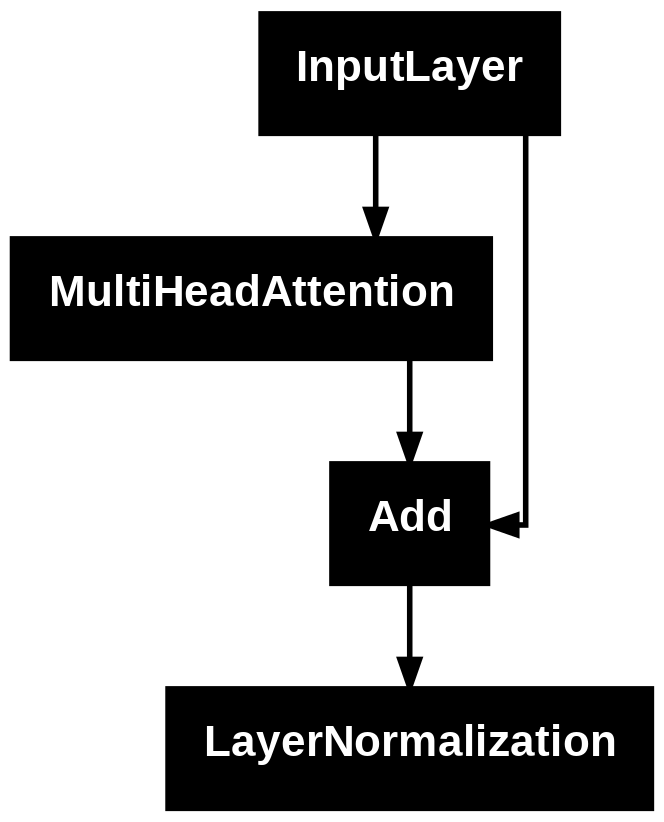

In [112]:
tf.keras.utils.plot_model(model)

In [113]:
def cross_attention(input_shape, context_shape, prefix='att', **kwargs):
    inputs = tf.keras.layers.Input(shape=input_shape, dtype=tf.float32, name=f'{prefix}_in2')
    context = tf.keras.layers.Input(shape=context_shape, dtype=tf.float32, name=f'{prefix}_ctx')

    attention = tf.keras.layers.MultiHeadAttention(
        name=f'{prefix}_att2',
        num_heads=kwargs.get('num_heads', 8),
        key_dim=kwargs.get('key_dim', 64)
    )

    norm = tf.keras.layers.LayerNormalization(name=f'{prefix}_norm2')
    add = tf.keras.layers.Add(name=f'{prefix}_add2')

    att_out = attention(
        query=inputs,
        value=context,
        key=context
    )
    output = norm(add([inputs, att_out]))

    return tf.keras.Model(inputs=[inputs, context], outputs=output, name=f'{prefix}_cross_att')

# Test cross-attention
cross_model = cross_attention(
    input_shape=(seq_length, embed_dim),
    context_shape=(seq_length, embed_dim),
    num_heads=num_heads,
    key_dim=key_dim
)

print(cross_model.summary())

# Test with sample data
test_input = tf.random.normal((1, seq_length, embed_dim))
test_context = tf.random.normal((1, seq_length, embed_dim))
test_output = cross_model([test_input, test_context])
print("\nCross-attention output shape:", test_output.shape)

Model: "att_cross_att"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ att_in2             │ (None, 25, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_ctx             │ (None, 25, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_att2            │ (None, 25, 512)   │  2,100,736 │ att_ctx[0][0],    │
│ (MultiHeadAttentio… │                   │            │ att_in2[0][0],    │
│                     │                   │            │ att_ctx[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_add2 (Add)      │ (None, 25, 512)   │          0 │ att_in2[0][0],    │
│                     │                   │            │ att_att2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ att_norm2           │ (None, 25, 512)   │      1,024 │ att_add2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,101,760 (8.02 MB)

 Trainable params: 2,101,760 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

None

Cross-attention output shape: (1, 25, 512)


In [114]:
model = cross_attention(
    input_shape=(seq_length, key_dim),
    context_shape=(seq_length, key_dim),
    num_heads=num_heads,
    key_dim=key_dim
)


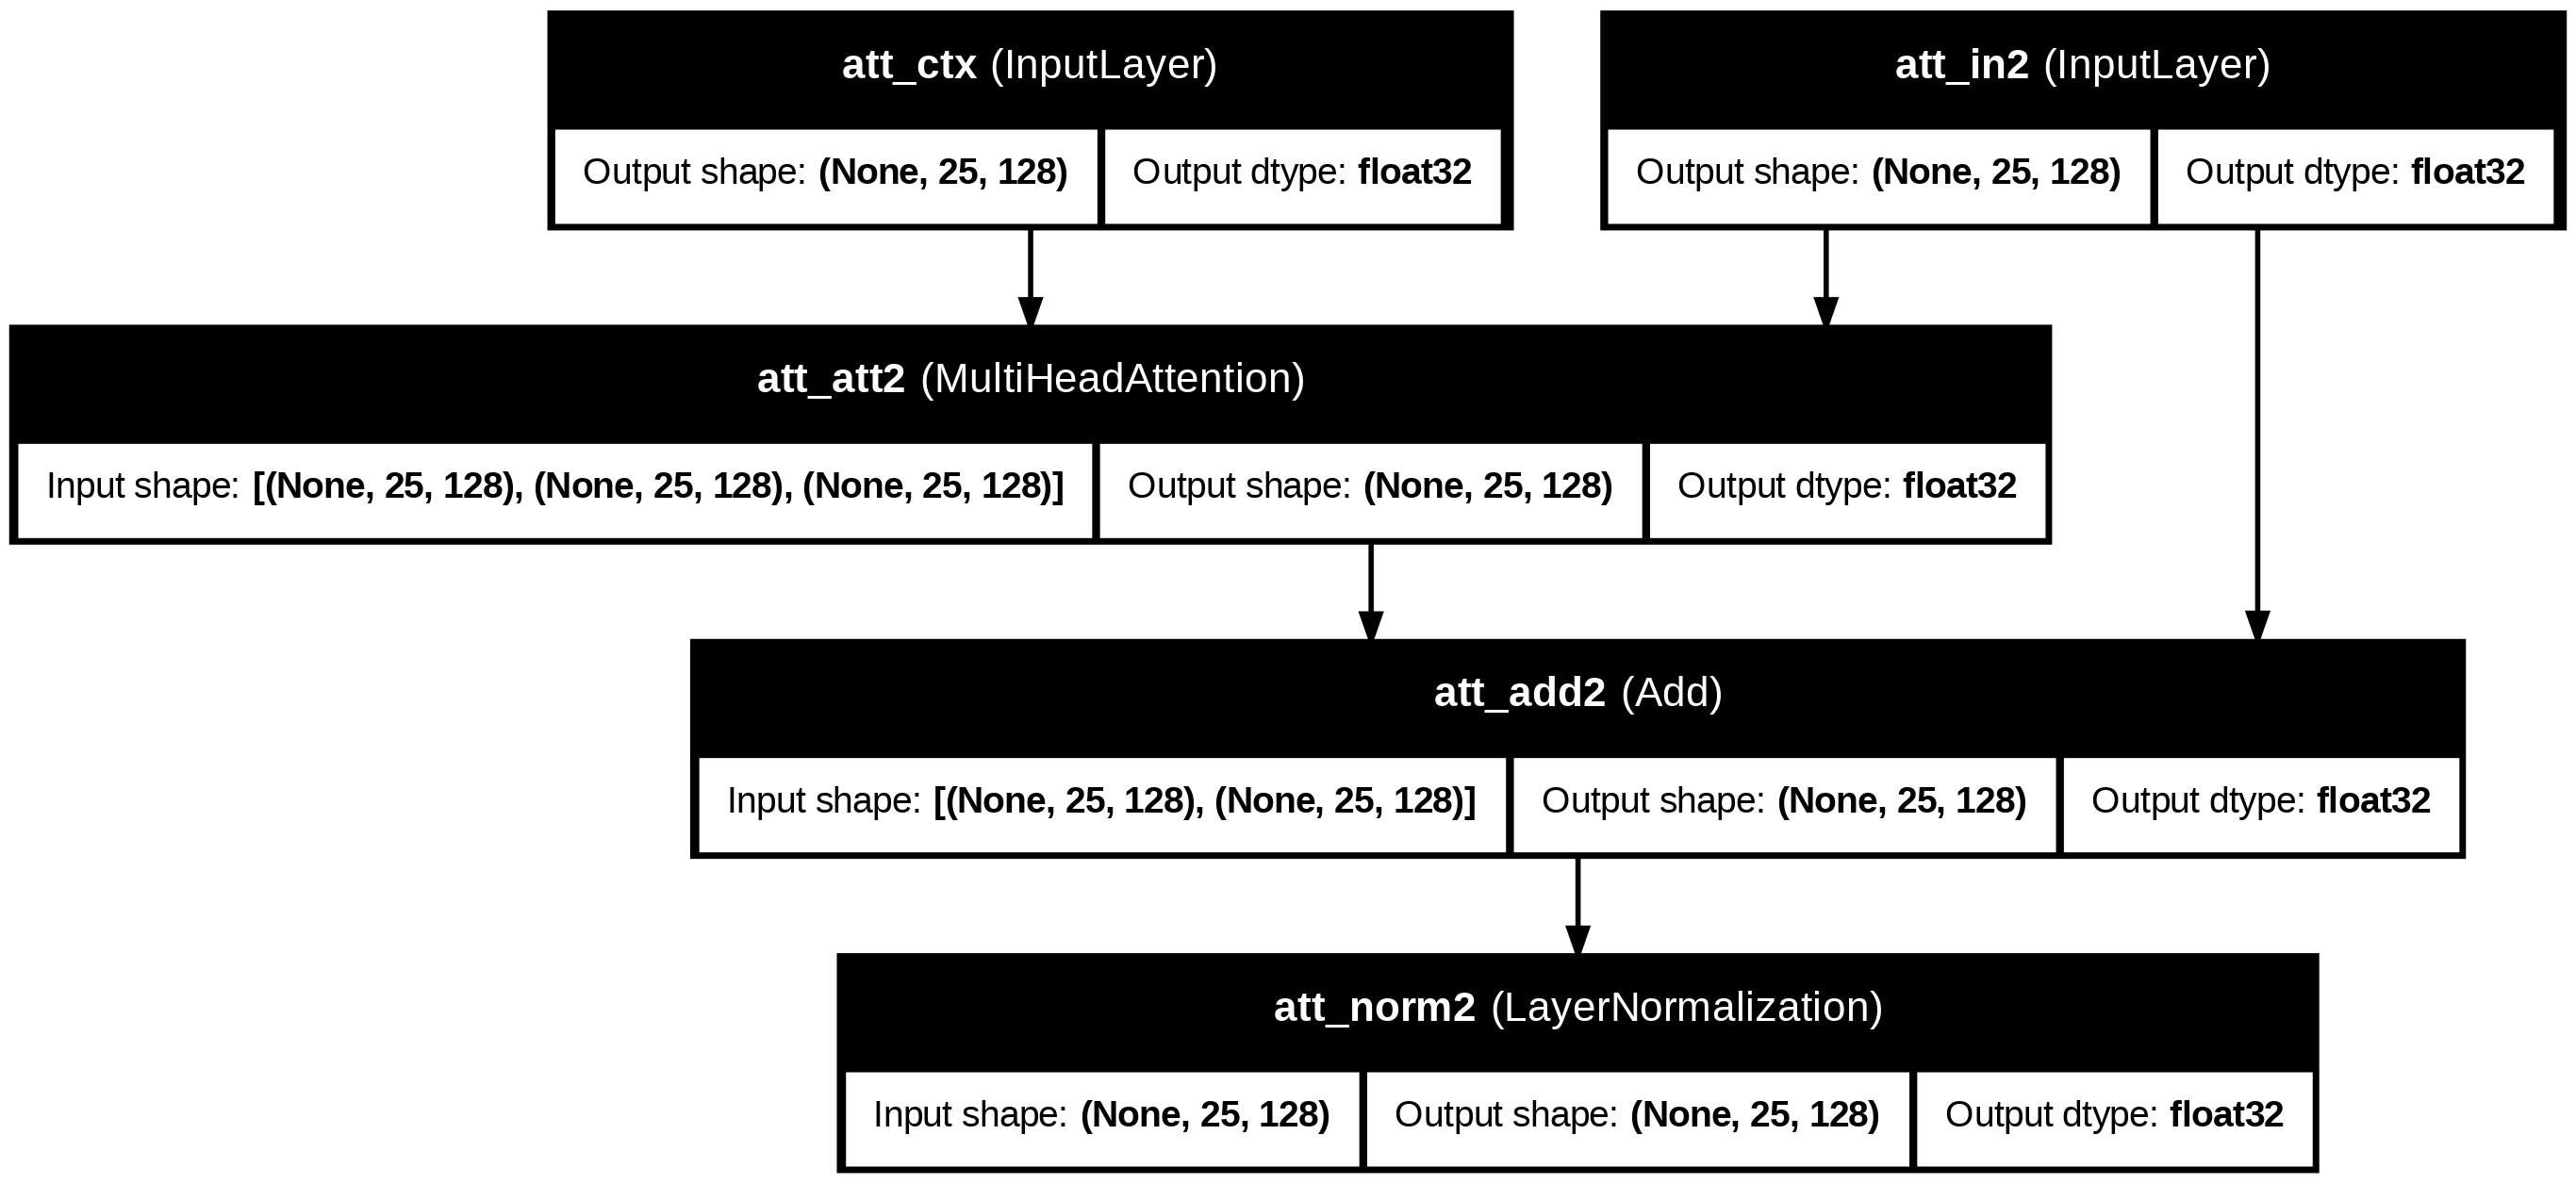

In [115]:
tf.keras.utils.plot_model(model,show_shapes=True,show_dtype=True,show_layer_names=True,show_layer_activations=True)

In [116]:
# Complete test of both attention mechanisms
def test_attention_layers():
    print("Testing Self-Attention:")
    print("-" * 50)

    # Test self-attention
    self_att = self_attention(
        input_shape=(seq_length, embed_dim),
        num_heads=num_heads,
        key_dim=key_dim
    )
    test_input = tf.random.normal((1, seq_length, embed_dim))
    output1 = self_att(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {output1.shape}")

    print("\nTesting Cross-Attention:")
    print("-" * 50)

    # Test cross-attention
    cross_att = cross_attention(
        input_shape=(seq_length, embed_dim),
        context_shape=(seq_length, embed_dim),
        num_heads=num_heads,
        key_dim=key_dim
    )
    test_context = tf.random.normal((1, seq_length, embed_dim))
    output2 = cross_att([test_input, test_context])
    print(f"Query shape: {test_input.shape}")
    print(f"Context shape: {test_context.shape}")
    print(f"Output shape: {output2.shape}")

# Run the tests
test_attention_layers()

Testing Self-Attention:
--------------------------------------------------
Input shape: (1, 25, 512)
Output shape: (1, 25, 512)

Testing Cross-Attention:
--------------------------------------------------
Query shape: (1, 25, 512)
Context shape: (1, 25, 512)
Output shape: (1, 25, 512)


In [117]:
def feed_forward(input_shape, model_dim, ff_dim, drop_out=0.1, prefix='ff'):
    inputs = tf.keras.layers.Input(shape=input_shape, dtype=tf.float32, name=f'{prefix}_in3')
    dense1 = tf.keras.layers.Dense(ff_dim, activation='relu', name=f'{prefix}_ff1')
    dense2 = tf.keras.layers.Dense(model_dim, name=f'{prefix}_ff2')
    drop = tf.keras.layers.Dropout(drop_out, name=f'{prefix}_drop')
    add = tf.keras.layers.Add(name=f'{prefix}_add3')
    norm = tf.keras.layers.LayerNormalization(name=f'{prefix}_norm3')

    ff_output = dense2(dense1(inputs))
    ff_output = drop(ff_output)
    output = norm(add([inputs, ff_output]))

    return tf.keras.Model(inputs=inputs, outputs=output, name=f'{prefix}_ff')


In [118]:
seq_length = 25
key_dim = 128
ff_dim = 512
model_dim = key_dim

ff_model = feed_forward(
    input_shape=(seq_length, key_dim),
    model_dim=model_dim,
    ff_dim=ff_dim
)



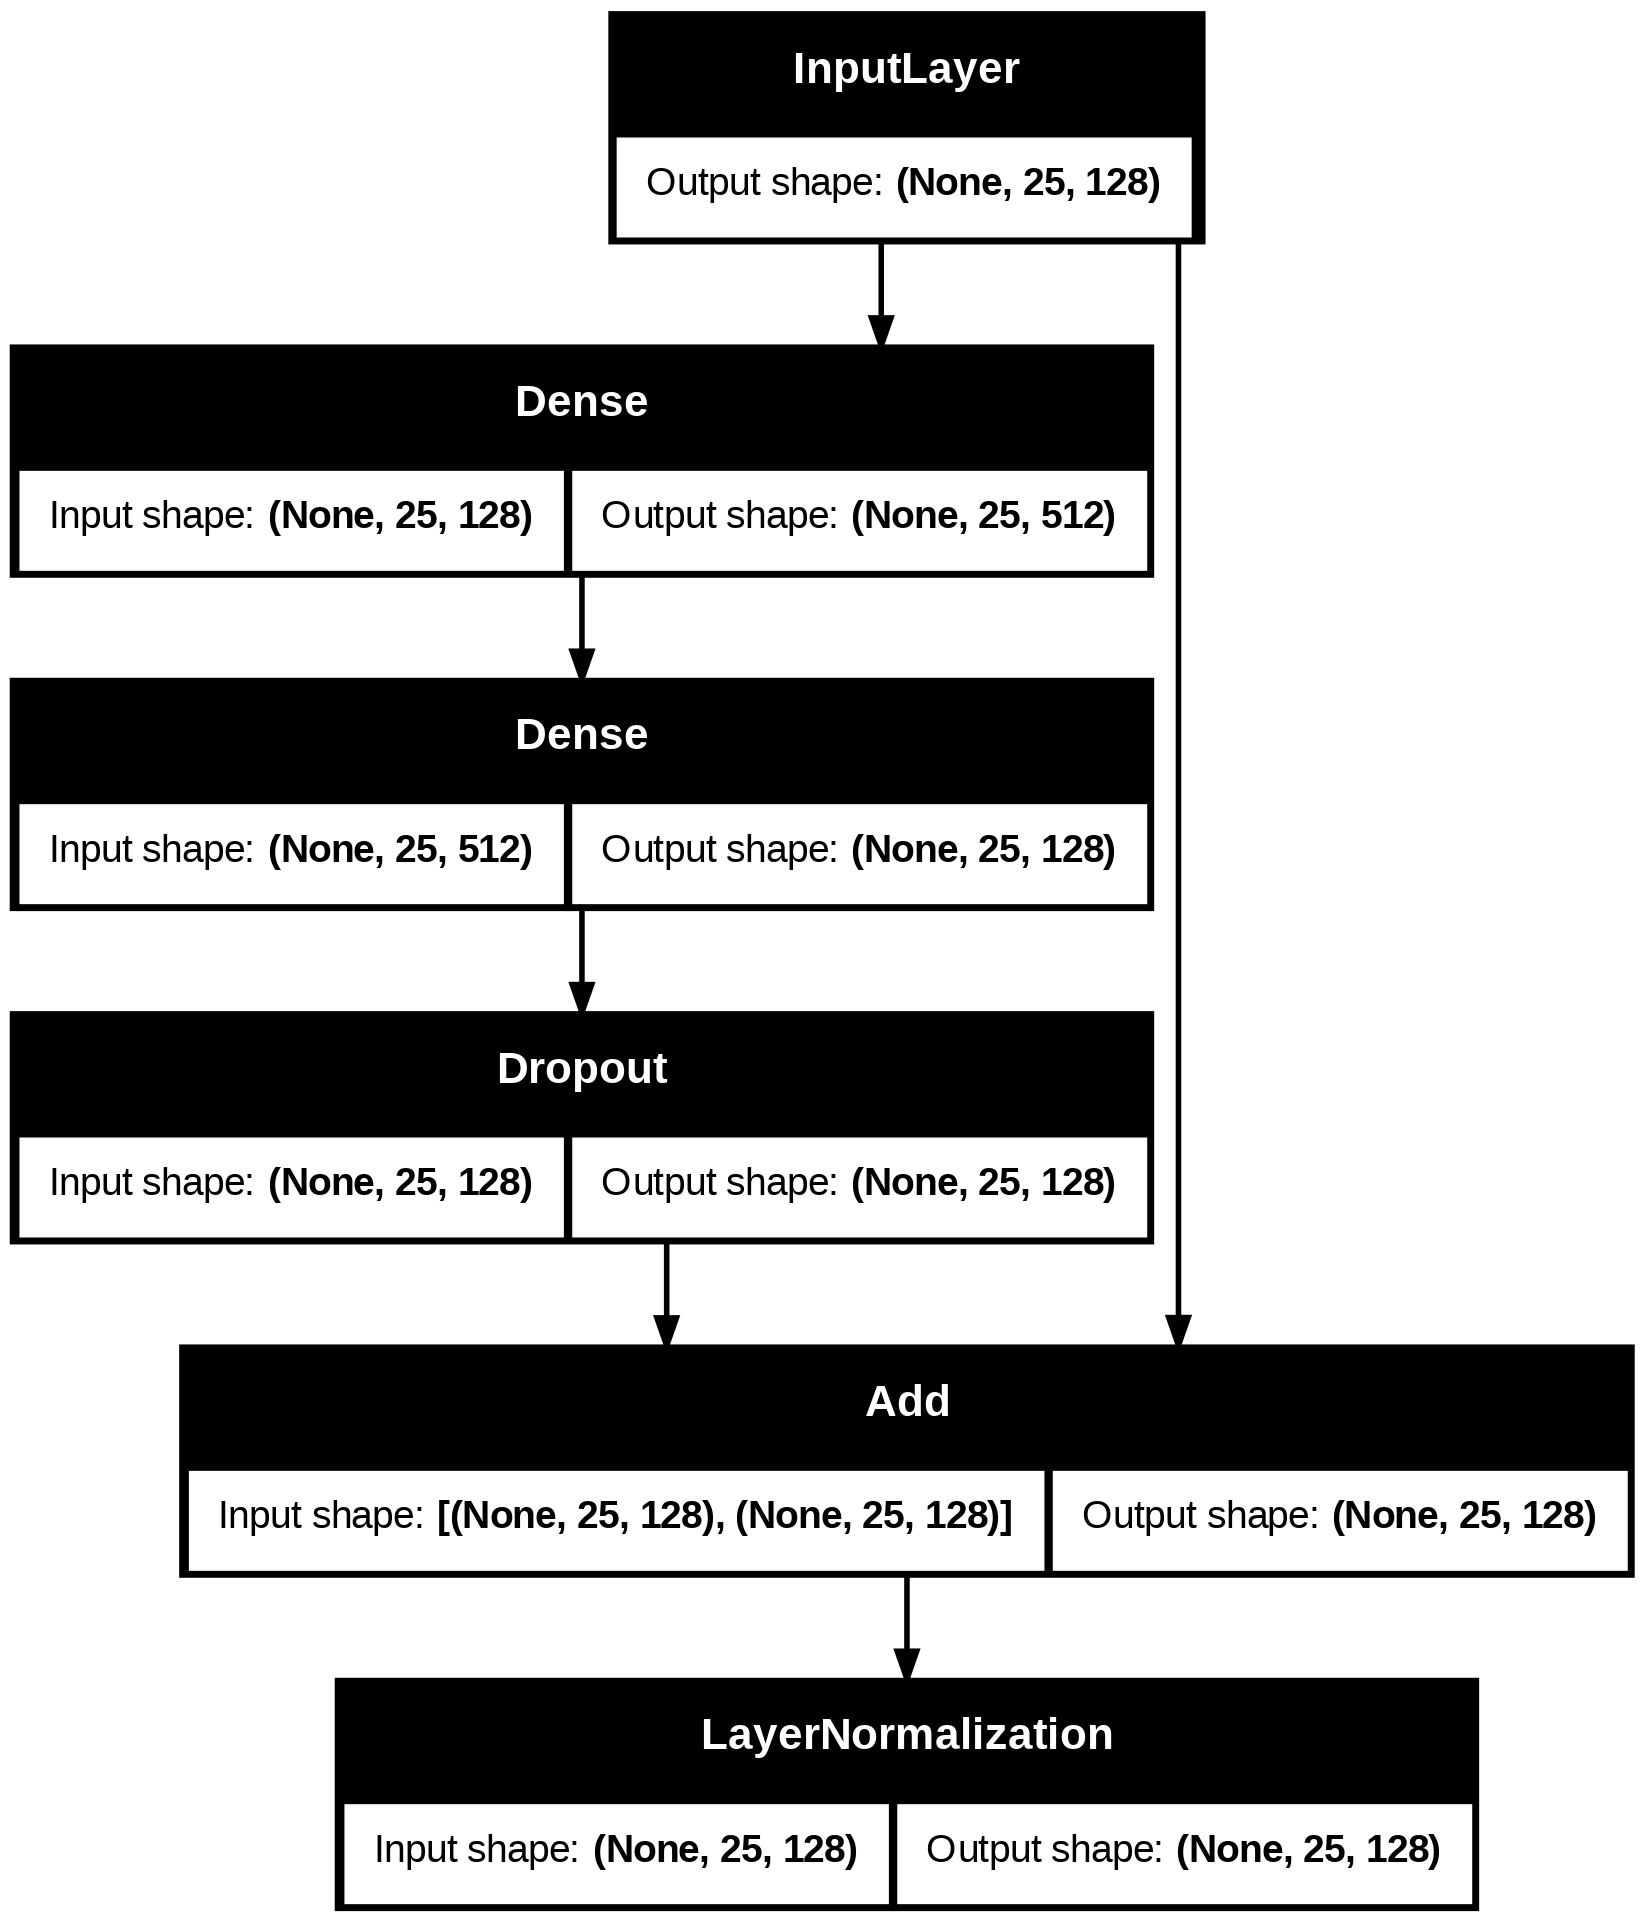

In [119]:
from tensorflow.keras.utils import plot_model
plot_model(ff_model, show_shapes=True, expand_nested=True)


#encoder decoder

In [120]:
def decoder(inputs, context, key_dim, ff_dim, drop_out=0.1, prefix='dec', **kwargs):
    # inputs and context are now tensors, not input layers

    # Get masks from inputs and context
    input_mask = tf.keras.backend.get_mask(inputs)
    context_mask = tf.keras.backend.get_mask(context)

    # Self attention with causal mask
    x = tf.keras.layers.MultiHeadAttention(
        name=f'{prefix}_attn1',
        num_heads=kwargs.get('num_heads', 8),
        key_dim=key_dim
    )(query=inputs, value=inputs, key=inputs, use_causal_mask=True, attention_mask=input_mask)

    norm1 = tf.keras.layers.LayerNormalization(name=f'{prefix}_norm1')
    add1 = tf.keras.layers.Add(name=f'{prefix}_add1')
    x = norm1(add1([inputs, x]))

    # Cross attention
    # Apply context mask to value and key explicitly
    context_masked = tf.where(tf.expand_dims(context_mask, axis=-1), context, tf.zeros_like(context))

    cross_attn_out = tf.keras.layers.MultiHeadAttention(
        name=f'{prefix}_att2',
        num_heads=kwargs.get('num_heads', 8),
        key_dim=key_dim
    )(query=x, value=context_masked, key=context_masked, attention_mask=input_mask) # Use input_mask for query mask


    norm2 = tf.keras.layers.LayerNormalization(name=f'{prefix}_norm2')
    add2 = tf.keras.layers.Add(name=f'{prefix}_add2')
    x = norm2(add2([x, cross_attn_out])) # Add residual connection and normalize

    # Feed forward
    ffmodel = feed_forward(input_shape=tf.keras.backend.int_shape(x)[1:], model_dim=key_dim, ff_dim=ff_dim, drop_out=drop_out, prefix=prefix)
    output = ffmodel(x)

    return output

In [121]:
def encoder(input_shape, key_dim, ff_dim, drop_out=0.1, prefix='enc', **kwargs):
    inputs = tf.keras.layers.Input(shape=input_shape, dtype=tf.float32, name=f'{prefix}_in0')

    # Self-attention
    attn_block = self_attention(input_shape=input_shape, prefix=prefix, key_dim=key_dim, mask=False, **kwargs)
    attn_out = attn_block(inputs)

    # Feed-forward
    ff_block = feed_forward(input_shape, model_dim=key_dim, ff_dim=ff_dim, drop_out=drop_out, prefix=prefix)
    ff_out = ff_block(attn_out)

    # Create model
    model = tf.keras.Model(inputs=inputs, outputs=ff_out, name=f'{prefix}_encoder')

    # Ensure mask propagation
    if hasattr(inputs, '_keras_mask'):
        model.output._keras_mask = inputs._keras_mask

    return model

def transformer(num_layers, num_heads, seq_length, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, name='transformer'):
    # Input layers
    input_enc = tf.keras.layers.Input(shape=(seq_length,), dtype=tf.int32, name='encode_inp')
    input_dec = tf.keras.layers.Input(shape=(seq_length-1,), dtype=tf.int32, name='decode_inp')

    # Embeddings
    emb_enc = PositionalEmbedding(seq_length, vocab_size_en, key_dim)(input_enc)
    emb_dec = PositionalEmbedding(seq_length-1, vocab_size_fr, key_dim)(input_dec)

    # Encoder stack
    x1 = emb_enc
    for i in range(num_layers):
        enc_layer = encoder(
            input_shape=(seq_length, key_dim),
            key_dim=key_dim,
            ff_dim=ff_dim,
            drop_out=dropout,
            prefix=f'enc{i}',
            num_heads=num_heads
        )
        x1 = enc_layer(x1)

    # Decoder stack
    x2 = emb_dec
    for i in range(num_layers):
        dec_layer = decoder(
            input_shape=(seq_length-1, key_dim),  # Decoder input shape
            context_shape=(seq_length, key_dim),   # Encoder output shape
            key_dim=key_dim,
            ff_dim=ff_dim,
            drop_out=dropout,
            prefix=f'dec{i}',
            num_heads=num_heads
        )
        x2 = dec_layer([x2, x1])  # x2: (None, 24, 128), x1: (None, 25, 128)

    # Final output
    output = tf.keras.layers.Dense(vocab_size_fr, name='linear')(x2)

    return tf.keras.Model(inputs=[input_enc, input_dec], outputs=output, name=name)

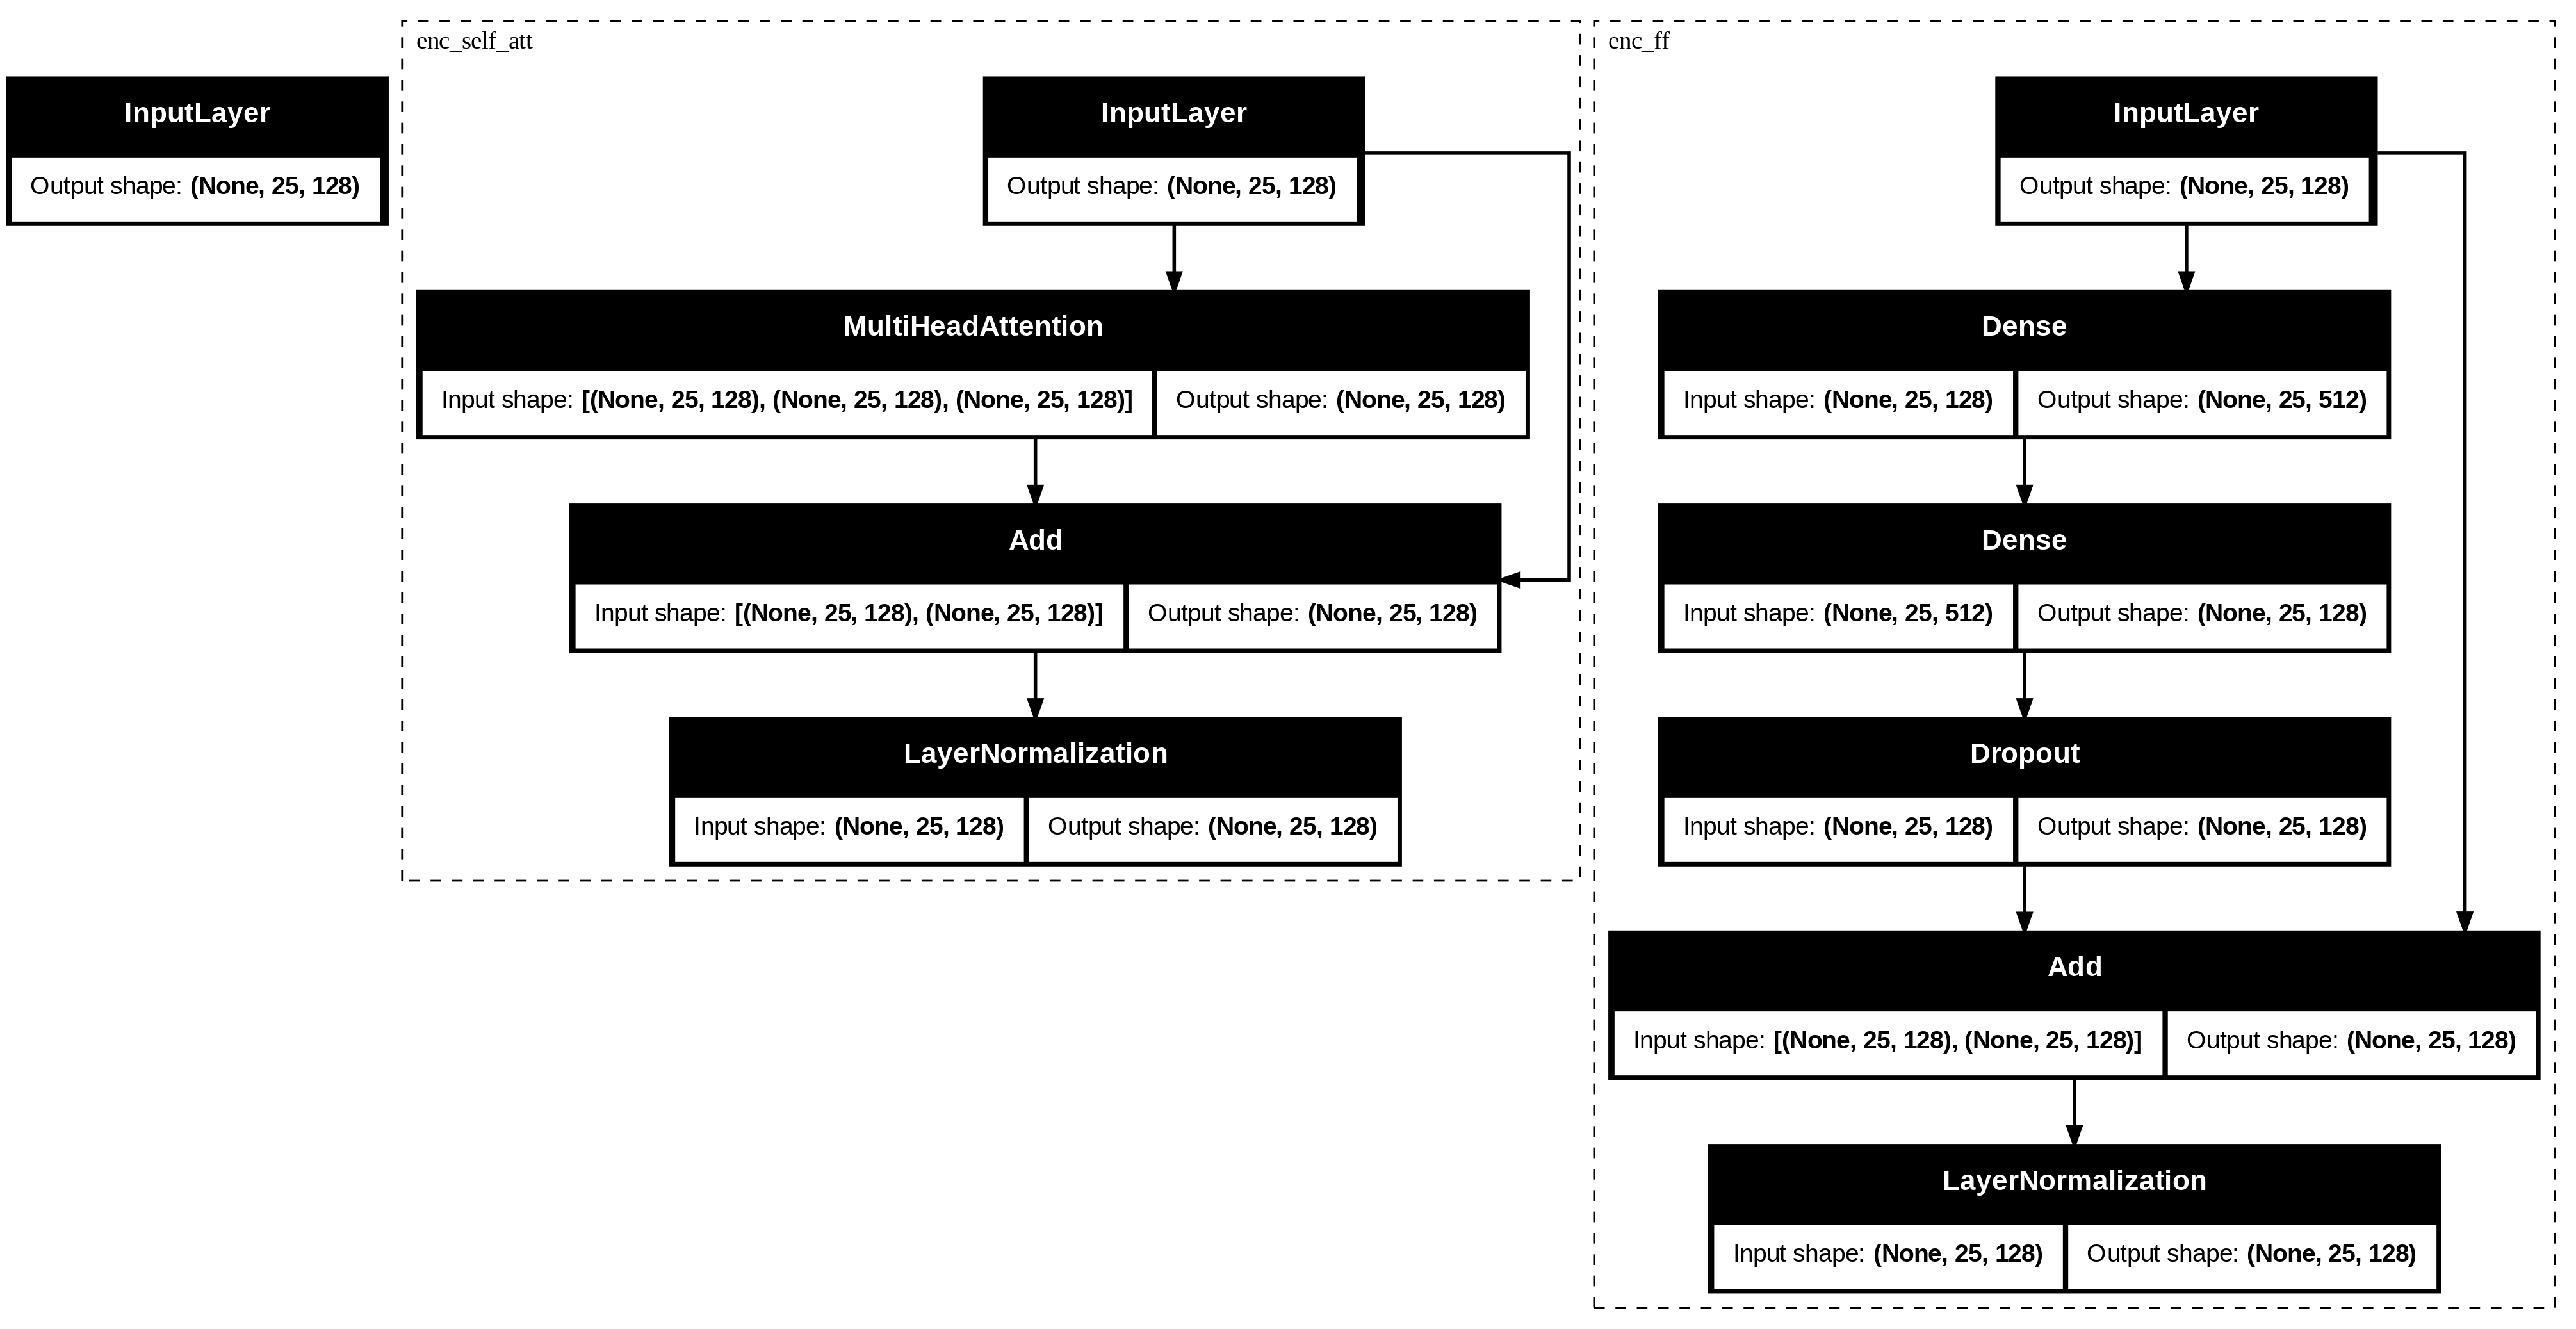

In [122]:
seq_length = 25
key_dim = 128
ff_dim = 512
num_heads = 8

model = encoder(
    input_shape=(seq_length, key_dim),
    key_dim=key_dim,
    ff_dim=ff_dim,
    num_heads=num_heads
)

tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=True)



In [123]:
import tensorflow as tf

seq_length = 25
key_dim=128
ff_dim=512
num_heads=8

model = decoder(
    input_shape=(seq_length, key_dim),
    context_shape=(seq_length, key_dim),
    key_dim=key_dim,
    ff_dim=ff_dim,
    num_heads=num_heads
)

tf.keras.utils.plot_model(model)

TypeError: decoder() missing 2 required positional arguments: 'inputs' and 'context'

In [ ]:
def transformer(num_layers, num_heads, seq_length, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, name='transformer'):
    input_enc = tf.keras.layers.Input(shape=(seq_length,), dtype=tf.int32, name='encode_inp')
    input_dec = tf.keras.layers.Input(shape=(seq_length - 1,), dtype=tf.int32, name='decode_inp')

    # Pass seq_length to the encoder's PositionalEmbedding
    emb_enc = PositionalEmbedding(seq_length, vocab_size_en, key_dim)(input_enc)
    # Pass seq_length - 1 to the decoder's PositionalEmbedding
    emb_dec = PositionalEmbedding(seq_length - 1, vocab_size_fr, key_dim)(input_dec)

    enc_output = emb_enc
    for i in range(num_layers):
        encoder_layer = encoder(
            input_shape=(seq_length, key_dim),
            key_dim=key_dim,
            ff_dim=ff_dim,
            drop_out=dropout,
            prefix=f'enc{i}',
            num_heads=num_heads
        )
        enc_output = encoder_layer(enc_output)

    # Print shape before decoder stack
    print(f"Shape of emb_dec before decoder stack: {tf.shape(emb_dec)}")

    dec_output = emb_dec
    for i in range(num_layers):
        # Print shape at the beginning of each decoder layer
        print(f"Shape of dec_output at start of decoder layer {i}: {tf.shape(dec_output)}")
        decoder_layer = decoder(
            input_shape=(seq_length - 1, key_dim),
            context_shape=(seq_length, key_dim),
            key_dim=key_dim,
            ff_dim=ff_dim,
            drop_out=dropout,
            prefix=f'dec{i}',
            num_heads=num_heads
        )
        dec_output = decoder_layer([dec_output, enc_output])
        # Print shape after each decoder layer
        print(f"Shape of dec_output after decoder layer {i}: {tf.shape(dec_output)}")


    output = tf.keras.layers.Dense(vocab_size_fr, name='linear')(dec_output)
    return tf.keras.Model(inputs=[input_enc, input_dec], outputs=output, name=name)

In [ ]:
# Use consistent parameters
seq_length = 25
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1

# Get actual vocabulary sizes from the vectorizers
vocab_size_en = len(eng_vect.get_vocabulary())
vocab_size_fr = len(fre_vect.get_vocabulary())

print(f"English vocabulary size: {vocab_size_en}")
print(f"French vocabulary size: {vocab_size_fr}")

model = transformer(
    num_layers=num_layers,
    num_heads=num_heads,
    seq_length=seq_length,
    key_dim=key_dim,
    ff_dim=ff_dim,
    vocab_size_en=vocab_size_en,
    vocab_size_fr=vocab_size_fr,
    dropout=dropout
)

model.summary()

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

In [ ]:
def make_dataset(pairs, batch_size=64):
    eng_texts = [pair[0] for pair in pairs]
    fre_texts = [pair[1] for pair in pairs]

    # Create dataset directly from tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, fre_texts))

    # Vectorize the data first
    dataset = dataset.map(lambda eng, fre: (eng_vect(eng), fre_vect(fre)), num_parallel_calls=tf.data.AUTOTUNE)

    # Then batch the vectorized data
    dataset = dataset.batch(batch_size)


    def format_fn(eng_tokens, fre_tokens):
        # Create proper input/output structure
        inputs = {
            'encode_inp': eng_tokens,
            'decode_inp': fre_tokens[:, :-1]  # Remove last token for decoder input
        }
        targets = fre_tokens[:, 1:]  # Remove first token for targets

        return inputs, targets

    # Apply formatting after batching
    dataset = (dataset
               .map(format_fn, num_parallel_calls=tf.data.AUTOTUNE)
               .prefetch(tf.data.AUTOTUNE)
               .cache() # Add caching for performance after vectorization and batching
              )

    return dataset

In [ ]:
# Recreate the datasets with correct input names
train_ds = make_dataset(train_pair)
test_ds = make_dataset(test_pair)

# Add validation to check the input structure
for inputs, targets in train_ds.take(1):
    print("Input keys:", inputs.keys())
    print("Input shapes:")
    for key, value in inputs.items():
        print(f"{key}: {value.shape}")
    print("Target shape:", targets.shape)

In [ ]:
train_ds = make_dataset(train_pair, batch_size=64)
test_ds = make_dataset(test_pair, batch_size=64)

In [ ]:
model = transformer(num_layers, num_heads, seq_length, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
history = model.fit(train_ds, epochs=5, validation_data=test_ds)

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(6,8), sharex=True)
fig.suptitle("training_history")

# Get the actual number of epochs from your history data
num_epochs = len(history.history['loss'])  # Fixed: history['history'] -> history.history
x = list(range(1, num_epochs + 1))

axes[0].plot(x, history.history['loss'], alpha=.5, label='loss')
axes[0].plot(x, history.history['val_loss'], alpha=.5, label='val_loss')
axes[0].set_ylabel('loss')
axes[0].legend(loc='upper right')

axes[1].plot(x, history.history['accuracy'], alpha=.5, label='accuracy')
axes[1].plot(x, history.history['val_accuracy'], alpha=.5, label='val_accuracy')
axes[1].set_ylabel('accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend(loc='upper right')

plt.show()

In [ ]:
from unicodedata import lookup
def translate(sentence):
    enc_tokens = eng_vect([sentence])
    vocab_lookup = list(fre_vect.get_vocabulary())  # renamed to avoid confusion
    start_sent, end_sent = "[start]", '[end]'
    output_sent = [start_sent]

    for i in range(seq_length):
        vector = fre_vect([' '.join(output_sent)])
        assert vector.shape == (1, seq_length+1)
        dec_tokens = vector[:, :-1]
        assert dec_tokens.shape == (1, seq_length)
        pred = model([enc_tokens, dec_tokens])
        assert pred.shape == (1, seq_length, vocab_size_fr)
        word = vocab_lookup[np.argmax(pred[0, i])]  # Changed from lookup() to list indexing
        if word == end_sent:
            break
        output_sent.append(word)
    return ' '.join(output_sent[1:])

In [ ]:
import random
seq_length=25
vocab_size_en=10000
vocab_size_fr=20000
test_count=20

for n in range(test_count):
  eng_sent,fre_sent=random.choice(test_pair)
  trans=translate(eng_sent)

  print(f"test case: {n}")
  print(f"English sentence: {eng_sent}")
  print(f"Translation value: {' '.join(trans)}")
  print(f"French sentence: {fre_sent}")
  print(f"Model translation: {trans}")


In [ ]:
# Load the data.
import os
import pathlib
import zipfile
import tensorflow as tf # Import tensorflow for get_file

# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# If the print statement below shows a different path, adjust this line
# print(f"Contents of extracted directory: {list(extracted_dir.iterdir())}") # Uncomment to debug extraction


PATH_TO_FILE = extracted_dir / "fra.txt" # Assuming fra.txt is directly in fra-eng_extracted


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
import random
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
import os # Import os for file operations
import pathlib # Import pathlib for path manipulation
import zipfile # Import zipfile for extraction
import random # Import random for data splitting

# Load the data.
# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# If the print statement below shows a different path, adjust this line
# print(f"Contents of extracted directory: {list(extracted_dir.iterdir())}") # Uncomment to debug extraction


PATH_TO_FILE = extracted_dir / "fra.txt" # Assuming fra.txt is directly in fra-eng_extracted


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")


# Define vocabulary size and sequence length
VOCAB_SIZE = 10000
MAX_LEN = 25

# Create English and French TextVectorization layers
eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)

# Adapt the vectorizers to the training data
train_eng_texts = [pair[0] for pair in train_pair]
train_fre_texts = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng_texts)
fre_vect.adapt(train_fre_texts)

print("English vocabulary size:", len(eng_vect.get_vocabulary()))
print("French vocabulary size:", len(fre_vect.get_vocabulary()))

In [ ]:
import tensorflow as tf

# Define parameters (including MAX_LEN)
MAX_LEN = 25  # Or the appropriate maximum sequence length
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


    def call(self, inputs, training=False):
        # Self-attention block
        # Rely on mask propagated from embedding layer
        attention_mask = inputs._keras_mask

        # Expand the attention mask for broadcasting with attention scores (batch_size, 1, 1, seq_len)
        # MultiHeadAttention expects attention_mask to be broadcastable to (..., seq_len_q, seq_len_k)
        # Input mask has shape (batch_size, seq_len)
        if attention_mask is not None:
             # Expand padding mask to (batch_size, 1, 1, seq_len_k) for broadcasting with attention scores
             attention_mask = tf.cast(attention_mask, dtype=tf.float32) # Cast to float32
             attention_mask = tf.expand_dims(tf.expand_dims(attention_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        attn_output = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask
        )
        attn_output = self.dropout1(attn_output, training=training)

        x = self.add1([inputs, attn_output])
        x = self.norm1(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout2(ff_output, training=training)

        x = self.add2([x, ff_output])
        output = self.norm2(x)

        # Propagate the mask
        output._keras_mask = inputs._keras_mask if hasattr(inputs, '_keras_mask') else None
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config


class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        # Masked self-attention
        # We will manually handle causal masking outside this layer call
        self.masked_self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        # Cross-attention
        self.cross_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


        # Feed-forward
        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm3 = tf.keras.layers.LayerNormalization()
        self.add3 = tf.keras.layers.Add()
        self.dropout3 = tf.keras.layers.Dropout(drop_out)

    def call(self, inputs, context, training=False):
        # Get masks from inputs and context (propagated from embedding)
        input_mask = inputs._keras_mask
        context_mask = context._keras_mask

        # Masked self-attention block - Manual Causal Masking
        seq_len_q = tf.shape(inputs)[1]
        seq_len_k = tf.shape(inputs)[1] # For self-attention, seq_len_q == seq_len_k

        # Manually create causal mask (seq_len_q, seq_len_k) and expand to (1, 1, seq_len_q, seq_len_k)
        causal_mask = tf.linalg.band_part(tf.ones((seq_len_q, seq_len_k), dtype=tf.float32), -1, 0)
        causal_mask = tf.expand_dims(tf.expand_dims(causal_mask, axis=0), axis=0) # (1, 1, seq_len_q, seq_len_k)


        # Create padding mask from input_mask and expand to (batch_size, 1, 1, seq_len_k)
        decoder_padding_mask = None
        if input_mask is not None:
             decoder_padding_mask = tf.cast(input_mask, dtype=tf.float32) # Cast to float32
             decoder_padding_mask = tf.expand_dims(tf.expand_dims(decoder_padding_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        # Combine causal mask with padding mask by multiplication (element-wise AND)
        combined_mask = causal_mask
        if decoder_padding_mask is not None:
            combined_mask = combined_mask * decoder_padding_mask


        # Pass the combined mask to MultiHeadAttention, disabling its internal causal mask
        attn1_output = self.masked_self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask, # Pass the manually combined mask
            use_causal_mask=False # Explicitly set causal mask to False
        )
        attn1_output = self.dropout1(attn1_output, training=training)


        x = self.add1([inputs, attn1_output])
        x = self.norm1(x)

        # Cross-attention block
        # Apply padding mask from encoder output to key/value
        encoder_padding_mask = None
        if context_mask is not None:
            # Expand context mask (batch_size, seq_len_k) to (batch_size, 1, 1, seq_len_k)
            encoder_padding_mask = tf.expand_dims(tf.expand_dims(tf.cast(context_mask, dtype=tf.float32), axis=1), axis=1)


        attn2_output = self.cross_attention(
            query=x,
            value=context,
            key=context,
            attention_mask=encoder_padding_mask # Apply padding mask from encoder output to key/value
        )
        attn2_output = self.dropout2(attn2_output, training=training)


        x = self.add2([x, attn2_output])
        x = self.norm2(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout3(ff_output, training=training)

        x = self.add3([x, ff_output])
        output = self.norm3(x)

        # Propagate the mask from the decoder input
        output._keras_mask = input_mask
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.masked_self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.masked_self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Keep mask_zero=True to generate padding mask automatically
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim, mask_zero=True
        )
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=seq_length, output_dim=embed_dim
        )
        self.seq_length = seq_length # Store seq_length

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs)
        # Generate positions based on the actual sequence length of the input batch
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        position_embeddings = self.position_embeddings(positions)

        # Expand position_embeddings to match the batch size of embedded_tokens
        position_embeddings = tf.expand_dims(position_embeddings, axis=0)
        position_embeddings = tf.tile(position_embeddings, [tf.shape(inputs)[0], 1, 1])

        # Add positional embeddings
        output = embedded_tokens + position_embeddings
        # Mask is automatically propagated from token_embeddings due to mask_zero=True

        return output

    # Keep compute_mask to propagate the mask
    def compute_mask(self, *args, **kwargs):
        return self.token_embeddings.compute_mask(*args, **kwargs)


    def get_config(self):
        config = super().get_config()
        config.update({
            'seq_length': self.seq_length,
            'vocab_size': self.token_embeddings.input_dim,
            'embed_dim': self.token_embeddings.output_dim
        })
        return config


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, num_heads, seq_length_enc, seq_length_dec, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        # Use mask_zero=True in PositionalEmbedding
        self.encoder_embedding = PositionalEmbedding(seq_length_enc, vocab_size_en, key_dim)
        self.decoder_embedding = PositionalEmbedding(seq_length_dec, vocab_size_fr, key_dim)

        self.encoder_layers = [
            TransformerEncoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]
        self.decoder_layers = [
            TransformerDecoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size_fr, name='linear')

    def call(self, inputs, training=False):
        encode_inp = inputs['encode_inp']
        decode_inp = inputs['decode_inp']

        # Embeddings
        # Masks are automatically generated and propagated by PositionalEmbedding
        enc_output = self.encoder_embedding(encode_inp)
        dec_output = self.decoder_embedding(decode_inp)

        # Encoder stack
        for encoder_layer in self.encoder_layers:
            # Masks are propagated to the layer
            enc_output = encoder_layer(enc_output, training=training)

        # Decoder stack
        for decoder_layer in self.decoder_layers:
            # Masks are propagated to the layer
            dec_output = decoder_layer(dec_output, enc_output, training=training)

        # Final linear layer
        output = self.final_layer(dec_output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_layers': len(self.encoder_layers),
            'num_heads': self.encoder_layers[0].self_attention.num_heads,
            'seq_length_enc': self.encoder_embedding.seq_length,
            'seq_length_dec': self.decoder_embedding.seq_length,
            'key_dim': self.encoder_layers[0].self_attention.key_dim,
            'ff_dim': self.encoder_layers[0].ff_network.layers[0].units,
            'vocab_size_en': self.encoder_embedding.token_embeddings.input_dim,
            'vocab_size_fr': self.decoder_embedding.token_embeddings.input_dim,
            'dropout': self.encoder_layers[0].dropout1.rate
        })
        return config

# Re-implement make_dataset to NOT generate and include padding masks explicitly
def make_dataset(pairs, batch_size=64):
    eng_texts = [pair[0] for pair in pairs]
    fre_texts = [pair[1] for pair in pairs]

    # Create dataset directly from tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, fre_texts))

    # Vectorize the data first
    dataset = dataset.map(lambda eng, fre: (eng_vect(eng), fre_vect(fre)), num_parallel_calls=tf.data.AUTOTUNE)

    # Then format the dataset
    def format_fn(eng_tokens, fre_tokens):
        # Create proper input/output structure
        inputs = {
            'encode_inp': eng_tokens,
            'decode_inp': fre_tokens[:, :-1],  # Remove last token for decoder input
        }
        targets = fre_tokens[:, 1:]  # Remove first token for targets

        return inputs, targets


    dataset = (dataset
               .batch(batch_size)
               .map(format_fn, num_parallel_calls=tf.data.AUTOTUNE)
               .prefetch(tf.data.AUTOTUNE)
               .cache()
              )

    return dataset


# Use consistent parameters
seq_length = MAX_LEN # Use MAX_LEN for seq_length
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1

# Get actual vocabulary sizes from the vectorizers
vocab_size_en = len(eng_vect.get_vocabulary())
vocab_size_fr = len(fre_vect.get_vocabulary())

# Recreate datasets with the fixed make_dataset function
train_ds = make_dataset(train_pair, batch_size=64)
val_ds = make_dataset(val_pair, batch_size=64) # Use validation data for monitoring

# Re-instantiate the model with the corrected layers
transformer_model = Transformer(
    num_layers=num_layers,
    num_heads=num_heads,
    seq_length_enc=seq_length,
    seq_length_dec=seq_length - 1,
    key_dim=key_dim,
    ff_dim=ff_dim,
    vocab_size_en=vocab_size_en,
    vocab_size_fr=vocab_size_fr,
    dropout=dropout
)

# Compile the model again
transformer_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary to check if it builds
transformer_model.summary()

# Train the model
history = transformer_model.fit(train_ds, epochs=5, validation_data=val_ds)

In [ ]:
import random
import numpy as np # Ensure numpy is imported

# Ensure seq_length is defined
# It should be defined in a previous cell, but defining it here
# as a fallback might be necessary if kernel state is inconsistent.
# Assuming seq_length is defined globally from model parameters (MAX_LEN)
global seq_length
global test_pair # Ensure test_pair is accessible
global transformer_model # Ensure transformer_model is accessible
global eng_vect # Ensure eng_vect is accessible
global fre_vect # Ensure fre_vect is accessible


# Define the translate function within this cell
def translate(sentence):
    # Declare global variables at the beginning
    global seq_length
    global fre_vect
    global transformer_model # Ensure transformer_model is also declared global
    global eng_vect # Ensure eng_vect is also declared global


    # Check if necessary global variables are defined
    if 'seq_length' not in globals() or seq_length is None:
        print("Error: seq_length is not defined.")
        return "Error: seq_length not defined."
    if 'fre_vect' not in globals() or fre_vect is None:
        print("Error: fre_vect is not defined.")
        return "Error: fre_vect not defined."
    if 'transformer_model' not in globals() or transformer_model is None:
        print("Error: transformer_model is not defined.")
        return "Error: Model not loaded."
    if 'eng_vect' not in globals() or eng_vect is None:
        print("Error: eng_vect is not defined.")
        return "Error: eng_vect not defined."


    enc_tokens = eng_vect([sentence])
    vocab_lookup = list(fre_vect.get_vocabulary())
    start_sent, end_sent = "[start]", '[end]'
    output_sent = [start_sent]

    decode_sequence_length = seq_length - 1
    if decode_sequence_length <= 0:
        return ""


    for i in range(seq_length): # Loop up to original seq_length


        vector = fre_vect([' '.join(output_sent)])[:, :decode_sequence_length]

        model_inputs = {
            'encode_inp': enc_tokens,
            'decode_inp': vector
        }


        pred = transformer_model(model_inputs)


        if i >= decode_sequence_length:
             break

        # The model output shape is (batch_size, seq_length_dec, vocab_size_fr)
        # We need the prediction for the token at position i in the output sequence,
        # which is based on the decoder input up to position i-1.
        # The decoder input has length decode_sequence_length (seq_length - 1).
        # The model output has predictions for positions 1 to seq_length - 1.
        # So, pred[0, i] gives the prediction for the token at position i+1.
        # We are building the output sequence token by token. In the i-th iteration (0-indexed),
        # output_sent has length i+1. We vectorize it and slice to decode_sequence_length.
        # The model output `pred` has shape `(1, decode_sequence_length, vocab_size_fr)`.
        # We need the prediction for the *next* token. The decoder input represents the sequence generated so far.
        # The model predicts the next token at each position of the decoder input.
        # So, `pred[0, -1, :]` gives the prediction for the token immediately following the current decoder input sequence.
        # Let's use pred[0, -1] to get the prediction for the *next* token based on the whole current sequence.

        predicted_token_index = np.argmax(pred[0, -1]) # Take prediction for the next token
        word = vocab_lookup[predicted_token_index]

        if word == end_sent:
            break
        output_sent.append(word)

    # Return the translated sentence, excluding the [start] token
    return ' '.join(output_sent[1:])


test_count=20

for n in range(test_count):
  # Check if test_pair is defined before using it
  if 'test_pair' not in globals() or test_pair is None:
      print(f"Error: test_pair is not defined. Cannot run test case {n}.")
      print("-" * 20)
      continue


  eng_sent,fre_sent=random.choice(test_pair)
  trans=translate(eng_sent)

  print(f"test case: {n}")
  print(f"English sentence: {eng_sent}")
  # The translate function now returns a string directly, not a list of tokens
  print(f"Model translation: {trans}")
  print(f"French sentence: {fre_sent}") # Compare with the actual French sentence
  print("-" * 20) # Separator for readability

In [ ]:
# Load the data.
import os
import pathlib
import zipfile
import tensorflow as tf # Import tensorflow for get_file
import random # Import random for data splitting

# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
# extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# Based on previous attempts, the file might be directly in the parent or in a subdirectory
# Let's try the original path structure again, as the zip might extract differently
# depending on the environment or tf.keras.utils.get_file version.
# The original path was path_to_zip.parent / "fra-eng" / "fra.txt"
# If that fails, we can try extracted_dir / "fra.txt" or other variations.
PATH_TO_FILE = path_to_zip.parent / "fra-eng" / "fra.txt"


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Define vocabulary size and sequence length
VOCAB_SIZE = 10000
MAX_LEN = 25

# Create English and French TextVectorization layers
eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)

# Adapt the vectorizers to the training data
train_eng_texts = [pair[0] for pair in train_pair]
train_fre_texts = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng_texts)
fre_vect.adapt(train_fre_texts)

print("English vocabulary size:", len(eng_vect.get_vocabulary()))
print("French vocabulary size:", len(fre_vect.get_vocabulary()))

In [ ]:
import random
import numpy as np # Ensure numpy is imported
import tensorflow as tf # Import tensorflow
from tensorflow.keras.layers import TextVectorization # Import TextVectorization
import os # Import os for file operations
import pathlib # Import pathlib for path manipulation
import zipfile # Import zipfile for extraction


# Define vocabulary size and sequence length (including MAX_LEN)
VOCAB_SIZE = 10000
MAX_LEN = 25 # Define MAX_LEN here


# Load the data.
# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# If the print statement below shows a different path, adjust this line
# print(f"Contents of extracted directory: {list(extracted_dir.iterdir())}") # Uncomment to debug extraction


# Assuming the extracted file is in a subdirectory named 'fra-eng' within the extracted directory
PATH_TO_FILE = extracted_dir / "fra.txt"


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")


# Use consistent parameters
seq_length = MAX_LEN # Use MAX_LEN for seq_length
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1


# Create English and French TextVectorization layers - THIS MUST BE AFTER train_pair IS DEFINED
eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)

# Adapt the vectorizers to the training data
train_eng_texts = [pair[0] for pair in train_pair]
train_fre_texts = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng_texts)
fre_vect.adapt(train_fre_texts)

print("English vocabulary size:", len(eng_vect.get_vocabulary()))
print("French vocabulary size:", len(fre_vect.get_vocabulary()))


# Define Transformer model layers and model
class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


    def call(self, inputs, training=False):
        # Self-attention block
        # Rely on mask propagated from embedding layer
        attention_mask = inputs._keras_mask

        # Expand the attention mask for broadcasting with attention scores (batch_size, 1, 1, seq_len)
        # MultiHeadAttention expects attention_mask to be broadcastable to (..., seq_len_q, seq_len_k)
        # Input mask has shape (batch_size, seq_len)
        if attention_mask is not None:
             # Expand padding mask to (batch_size, 1, 1, seq_len_k) for broadcasting with attention scores
             attention_mask = tf.cast(attention_mask, dtype=tf.float32) # Cast to float32
             attention_mask = tf.expand_dims(tf.expand_dims(attention_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        attn_output = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask
        )
        attn_output = self.dropout1(attn_output, training=training)

        x = self.add1([inputs, attn_output])
        x = self.norm1(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout2(ff_output, training=training)

        x = self.add2([x, ff_output])
        output = self.norm2(x)

        # Propagate the mask
        output._keras_mask = inputs._keras_mask if hasattr(inputs, '_keras_mask') else None
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config


class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        # Masked self-attention
        # We will manually handle causal masking outside this layer call
        self.masked_self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        # Cross-attention
        self.cross_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


        # Feed-forward
        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm3 = tf.keras.layers.LayerNormalization()
        self.add3 = tf.keras.layers.Add()
        self.dropout3 = tf.keras.layers.Dropout(drop_out)

    def call(self, inputs, context, training=False):
        # Get masks from inputs and context (propagated from embedding)
        input_mask = inputs._keras_mask
        context_mask = context._keras_mask

        # Masked self-attention block - Manual Causal Masking
        seq_len_q = tf.shape(inputs)[1]
        seq_len_k = tf.shape(inputs)[1] # For self-attention, seq_len_q == seq_len_k

        # Manually create causal mask (seq_len_q, seq_len_k) and expand to (1, 1, seq_len_q, seq_len_k)
        causal_mask = tf.linalg.band_part(tf.ones((seq_len_q, seq_len_k), dtype=tf.float32), -1, 0)
        causal_mask = tf.expand_dims(tf.expand_dims(causal_mask, axis=0), axis=0) # (1, 1, seq_len_q, seq_len_k)


        # Create padding mask from input_mask and expand to (batch_size, 1, 1, seq_len_k)
        decoder_padding_mask = None
        if input_mask is not None:
             decoder_padding_mask = tf.cast(input_mask, dtype=tf.float32) # Cast to float32
             decoder_padding_mask = tf.expand_dims(tf.expand_dims(decoder_padding_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        # Combine causal mask with padding mask by multiplication (element-wise AND)
        combined_mask = causal_mask
        if decoder_padding_mask is not None:
            combined_mask = combined_mask * decoder_padding_mask


        # Pass the combined mask to MultiHeadAttention, disabling its internal causal mask
        attn1_output = self.masked_self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask, # Pass the manually combined mask
            use_causal_mask=False # Explicitly set causal mask to False
        )
        attn1_output = self.dropout1(attn1_output, training=training)


        x = self.add1([inputs, attn1_output])
        x = self.norm1(x)

        # Cross-attention block
        # Apply padding mask from encoder output to key/value
        encoder_padding_mask = None
        if context_mask is not None:
            # Expand context mask (batch_size, seq_len_k) to (batch_size, 1, 1, seq_len_k)
            encoder_padding_mask = tf.expand_dims(tf.expand_dims(tf.cast(context_mask, dtype=tf.float32), axis=1), axis=1)


        attn2_output = self.cross_attention(
            query=x,
            value=context,
            key=context,
            attention_mask=encoder_padding_mask # Apply padding mask from encoder output to key/value
        )
        attn2_output = self.dropout2(attn2_output, training=training)


        x = self.add2([x, attn2_output])
        x = self.norm2(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout3(ff_output, training=training)

        x = self.add3([x, ff_output])
        output = self.norm3(x)

        # Propagate the mask from the decoder input
        output._keras_mask = input_mask
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.masked_self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.masked_self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Keep mask_zero=True to generate padding mask automatically
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim, mask_zero=True
        )
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=seq_length, output_dim=embed_dim
        )
        self.seq_length = seq_length # Store seq_length

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs)
        # Generate positions based on the actual sequence length of the input batch
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        position_embeddings = self.position_embeddings(positions)

        # Expand position_embeddings to match the batch size of embedded_tokens
        position_embeddings = tf.expand_dims(position_embeddings, axis=0)
        position_embeddings = tf.tile(position_embeddings, [tf.shape(inputs)[0], 1, 1])

        # Add positional embeddings
        output = embedded_tokens + position_embeddings
        # Mask is automatically propagated from token_embeddings due to mask_zero=True

        return output

    # Keep compute_mask to propagate the mask
    def compute_mask(self, *args, **kwargs):
        return self.token_embeddings.compute_mask(*args, **kwargs)


    def get_config(self):
        config = super().get_config()
        config.update({
            'seq_length': self.seq_length,
            'vocab_size': self.token_embeddings.input_dim,
            'embed_dim': self.token_embeddings.output_dim
        })
        return config


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, num_heads, seq_length_enc, seq_length_dec, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        # Use mask_zero=True in PositionalEmbedding
        self.encoder_embedding = PositionalEmbedding(seq_length_enc, vocab_size_en, key_dim)
        self.decoder_embedding = PositionalEmbedding(seq_length_dec, vocab_size_fr, key_dim)

        self.encoder_layers = [
            TransformerEncoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]
        self.decoder_layers = [
            TransformerDecoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size_fr, name='linear')

    def call(self, inputs, training=False):
        encode_inp = inputs['encode_inp']
        decode_inp = inputs['decode_inp']

        # Embeddings
        # Masks are automatically generated and propagated by PositionalEmbedding
        enc_output = self.encoder_embedding(encode_inp)
        dec_output = self.decoder_embedding(decode_inp)

        # Encoder stack
        for encoder_layer in self.encoder_layers:
            # Masks are propagated to the layer
            enc_output = encoder_layer(enc_output, training=training)

        # Decoder stack
        for decoder_layer in self.decoder_layers:
            # Masks are propagated to the layer
            dec_output = decoder_layer(dec_output, enc_output, training=training)

        # Final linear layer
        output = self.final_layer(dec_output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_layers': len(self.encoder_layers),
            'num_heads': self.encoder_layers[0].self_attention.num_heads,
            'seq_length_enc': self.encoder_embedding.seq_length,
            'seq_length_dec': self.decoder_embedding.seq_length,
            'key_dim': self.encoder_layers[0].self_attention.key_dim,
            'ff_dim': self.encoder_layers[0].ff_network.layers[0].units,
            'vocab_size_en': self.encoder_embedding.token_embeddings.input_dim,
            'vocab_size_fr': self.decoder_embedding.token_embeddings.input_dim,
            'dropout': self.encoder_layers[0].dropout1.rate
        })
        return config

# Re-implement make_dataset to NOT generate and include padding masks explicitly
def make_dataset(pairs, batch_size=64):
    eng_texts = [pair[0] for pair in pairs]
    fre_texts = [pair[1] for pair in pairs]

    # Create dataset directly from tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, fre_texts))

    # Vectorize the data first
    dataset = dataset.map(lambda eng, fre: (eng_vect(eng), fre_vect(fre)), num_parallel_calls=tf.data.AUTOTUNE)

    # Then format the dataset
    def format_fn(eng_tokens, fre_tokens):
        # Create proper input/output structure
        inputs = {
            'encode_inp': eng_tokens,
            'decode_inp': fre_tokens[:, :-1],  # Remove last token for decoder input
        }
        targets = fre_tokens[:, 1:]  # Remove first token for targets

        return inputs, targets


    dataset = (dataset
               .batch(batch_size)
               .map(format_fn, num_parallel_calls=tf.data.AUTOTUNE)
               .prefetch(tf.data.AUTOTUNE)
               .cache()
              )

    return dataset


# Use consistent parameters
# seq_length is defined from MAX_LEN above
# num_layers = 6
# num_heads = 16
# key_dim = 128
# ff_dim = 512
# dropout = 0.1

# Get actual vocabulary sizes from the vectorizers
vocab_size_en = len(eng_vect.get_vocabulary())
vocab_size_fr = len(fre_vect.get_vocabulary())

# Recreate datasets with the fixed make_dataset function
train_ds = make_dataset(train_pair, batch_size=64)
val_ds = make_dataset(val_pair, batch_size=64) # Use validation data for monitoring

# Re-instantiate the model with the corrected layers
transformer_model = Transformer(
    num_layers=num_layers,
    num_heads=num_heads,
    seq_length_enc=seq_length,
    seq_length_dec=seq_length - 1,
    key_dim=key_dim,
    ff_dim=ff_dim,
    vocab_size_en=vocab_size_en,
    vocab_size_fr=vocab_size_fr,
    dropout=dropout
)

# Compile the model again
transformer_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary to check if it builds
transformer_model.summary()

# Train the model
print("Starting model training...")
history = transformer_model.fit(train_ds, epochs=5, validation_data=val_ds)
print("Model training finished.")


# Ensure seq_length, test_pair, transformer_model, eng_vect, fre_vect are accessible globally
global seq_length
global test_pair
global transformer_model
global eng_vect
global fre_vect


# Define the translate function within this cell
def translate(sentence):
    # Declare global variables at the beginning
    global seq_length
    global fre_vect
    global transformer_model
    global eng_vect


    # Check if necessary global variables are defined
    if 'seq_length' not in globals() or seq_length is None:
        print("Error: seq_length is not defined.")
        return "Error: seq_length not defined."
    if 'fre_vect' not in globals() or fre_vect is None:
        print("Error: fre_vect is not defined.")
        return "Error: fre_vect not defined."
    if 'transformer_model' not in globals() or transformer_model is None:
        print("Error: transformer_model is not defined.")
        return "Error: Model not loaded."
    if 'eng_vect' not in globals() or eng_vect is None:
        print("Error: eng_vect is not defined.")
        return "Error: eng_vect not defined."


    enc_tokens = eng_vect([sentence])
    vocab_lookup = list(fre_vect.get_vocabulary())
    start_sent, end_sent = "[start]", '[end]'
    output_sent = [start_sent]

    decode_sequence_length = seq_length - 1
    if decode_sequence_length <= 0:
        return ""


    for i in range(seq_length):


        vector = fre_vect([' '.join(output_sent)])[:, :decode_sequence_length]

        model_inputs = {
            'encode_inp': enc_tokens,
            'decode_inp': vector
        }


        pred = transformer_model(model_inputs)


        if i >= decode_sequence_length:
             break

        predicted_token_index = np.argmax(pred[0, -1])
        word = vocab_lookup[predicted_token_index]

        if word == end_sent:
            break
        output_sent.append(word)

    return ' '.join(output_sent[1:])


test_count=20

for n in range(test_count):
  # Check if test_pair is defined before using it
  if 'test_pair' not in globals() or test_pair is None:
      print(f"Error: test_pair is not defined. Cannot run test case {n}.")
      print("-" * 20)
      continue


  eng_sent,fre_sent=random.choice(test_pair)
  trans=translate(eng_sent)

  print(f"test case: {n}")
  print(f"English sentence: {eng_sent}")
  print(f"Model translation: {trans}")
  print(f"French sentence: {fre_sent}")
  print("-" * 20)

In [ ]:
# Load the data.
import os
import pathlib
import zipfile
import tensorflow as tf # Import tensorflow for get_file
import random # Import random for data splitting

# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
# extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# Based on previous attempts, the file might be directly in the parent or in a subdirectory
# Let's try the original path structure again, as the zip might extract differently
# depending on the environment or tf.keras.utils.get_file version.
# The original path was path_to_zip.parent / "fra-eng" / "fra.txt"
# If that fails, we can try extracted_dir / "fra.txt" or other variations.
PATH_TO_FILE = path_to_zip.parent / "fra-eng" / "fra.txt"


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Define vocabulary size and sequence length
VOCAB_SIZE = 10000
MAX_LEN = 25

# Create English and French TextVectorization layers
eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)

# Adapt the vectorizers to the training data
train_eng_texts = [pair[0] for pair in train_pair]
train_fre_texts = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng_texts)
fre_vect.adapt(train_fre_texts)

print("English vocabulary size:", len(eng_vect.get_vocabulary()))
print("French vocabulary size:", len(fre_vect.get_vocabulary()))

In [ ]:
import tensorflow as tf

# Define parameters (including MAX_LEN)
MAX_LEN = 25  # Or the appropriate maximum sequence length
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


    def call(self, inputs, training=False):
        # Self-attention block
        # Rely on mask propagated from embedding layer
        attention_mask = inputs._keras_mask

        # Expand the attention mask for broadcasting with attention scores (batch_size, 1, 1, seq_len)
        # MultiHeadAttention expects attention_mask to be broadcastable to (..., seq_len_q, seq_len_k)
        # Input mask has shape (batch_size, seq_len)
        if attention_mask is not None:
             # Expand padding mask to (batch_size, 1, 1, seq_len_k) for broadcasting with attention scores
             attention_mask = tf.cast(attention_mask, dtype=tf.float32) # Cast to float32
             attention_mask = tf.expand_dims(tf.expand_dims(attention_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        attn_output = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask
        )
        attn_output = self.dropout1(attn_output, training=training)

        x = self.add1([inputs, attn_output])
        x = self.norm1(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout2(ff_output, training=training)

        x = self.add2([x, ff_output])
        output = self.norm2(x)

        # Propagate the mask
        output._keras_mask = inputs._keras_mask if hasattr(inputs, '_keras_mask') else None
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config


class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        # Masked self-attention
        # We will manually handle causal masking outside this layer call
        self.masked_self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        # Cross-attention
        self.cross_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


        # Feed-forward
        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm3 = tf.keras.layers.LayerNormalization()
        self.add3 = tf.keras.layers.Add()
        self.dropout3 = tf.keras.layers.Dropout(drop_out)

    def call(self, inputs, context, training=False):
        # Get masks from inputs and context (propagated from embedding)
        input_mask = inputs._keras_mask
        context_mask = context._keras_mask

        # Masked self-attention block - Manual Causal Masking
        seq_len_q = tf.shape(inputs)[1]
        seq_len_k = tf.shape(inputs)[1] # For self-attention, seq_len_q == seq_len_k

        # Manually create causal mask (seq_len_q, seq_len_k) and expand to (1, 1, seq_len_q, seq_len_k)
        causal_mask = tf.linalg.band_part(tf.ones((seq_len_q, seq_len_k), dtype=tf.float32), -1, 0)
        causal_mask = tf.expand_dims(tf.expand_dims(causal_mask, axis=0), axis=0) # (1, 1, seq_len_q, seq_len_k)


        # Create padding mask from input_mask and expand to (batch_size, 1, 1, seq_len_k)
        decoder_padding_mask = None
        if input_mask is not None:
             decoder_padding_mask = tf.cast(input_mask, dtype=tf.float32) # Cast to float32
             decoder_padding_mask = tf.expand_dims(tf.expand_dims(decoder_padding_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        # Combine causal mask with padding mask by multiplication (element-wise AND)
        combined_mask = causal_mask
        if decoder_padding_mask is not None:
            combined_mask = combined_mask * decoder_padding_mask


        # Pass the combined mask to MultiHeadAttention, disabling its internal causal mask
        attn1_output = self.masked_self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask, # Pass the manually combined mask
            use_causal_mask=False # Explicitly set causal mask to False
        )
        attn1_output = self.dropout1(attn1_output, training=training)


        x = self.add1([inputs, attn1_output])
        x = self.norm1(x)

        # Cross-attention block
        # Apply padding mask from encoder output to key/value
        encoder_padding_mask = None
        if context_mask is not None:
            # Expand context mask (batch_size, seq_len_k) to (batch_size, 1, 1, seq_len_k)
            encoder_padding_mask = tf.expand_dims(tf.expand_dims(tf.cast(context_mask, dtype=tf.float32), axis=1), axis=1)


        attn2_output = self.cross_attention(
            query=x,
            value=context,
            key=context,
            attention_mask=encoder_padding_mask # Apply padding mask from encoder output to key/value
        )
        attn2_output = self.dropout2(attn2_output, training=training)


        x = self.add2([x, attn2_output])
        x = self.norm2(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout3(ff_output, training=training)

        x = self.add3([x, ff_output])
        output = self.norm3(x)

        # Propagate the mask from the decoder input
        output._keras_mask = input_mask
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.masked_self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.masked_self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Keep mask_zero=True to generate padding mask automatically
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim, mask_zero=True
        )
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=seq_length, output_dim=embed_dim
        )
        self.seq_length = seq_length # Store seq_length

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs)
        # Generate positions based on the actual sequence length of the input batch
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        position_embeddings = self.position_embeddings(positions)

        # Expand position_embeddings to match the batch size of embedded_tokens
        position_embeddings = tf.expand_dims(position_embeddings, axis=0)
        position_embeddings = tf.tile(position_embeddings, [tf.shape(inputs)[0], 1, 1])

        # Add positional embeddings
        output = embedded_tokens + position_embeddings
        # Mask is automatically propagated from token_embeddings due to mask_zero=True

        return output

    # Keep compute_mask to propagate the mask
    def compute_mask(self, *args, **kwargs):
        return self.token_embeddings.compute_mask(*args, **kwargs)


    def get_config(self):
        config = super().get_config()
        config.update({
            'seq_length': self.seq_length,
            'vocab_size': self.token_embeddings.input_dim,
            'embed_dim': self.token_embeddings.output_dim
        })
        return config


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, num_heads, seq_length_enc, seq_length_dec, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        # Use mask_zero=True in PositionalEmbedding
        self.encoder_embedding = PositionalEmbedding(seq_length_enc, vocab_size_en, key_dim)
        self.decoder_embedding = PositionalEmbedding(seq_length_dec, vocab_size_fr, key_dim)

        self.encoder_layers = [
            TransformerEncoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]
        self.decoder_layers = [
            TransformerDecoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size_fr, name='linear')

    def call(self, inputs, training=False):
        encode_inp = inputs['encode_inp']
        decode_inp = inputs['decode_inp']

        # Embeddings
        # Masks are automatically generated and propagated by PositionalEmbedding
        enc_output = self.encoder_embedding(encode_inp)
        dec_output = self.decoder_embedding(decode_inp)

        # Encoder stack
        for encoder_layer in self.encoder_layers:
            # Masks are propagated to the layer
            enc_output = encoder_layer(enc_output, training=training)

        # Decoder stack
        for decoder_layer in self.decoder_layers:
            # Masks are propagated to the layer
            dec_output = decoder_layer(dec_output, enc_output, training=training)

        # Final linear layer
        output = self.final_layer(dec_output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_layers': len(self.encoder_layers),
            'num_heads': self.encoder_layers[0].self_attention.num_heads,
            'seq_length_enc': self.encoder_embedding.seq_length,
            'seq_length_dec': self.decoder_embedding.seq_length,
            'key_dim': self.encoder_layers[0].self_attention.key_dim,
            'ff_dim': self.encoder_layers[0].ff_network.layers[0].units,
            'vocab_size_en': self.encoder_embedding.token_embeddings.input_dim,
            'vocab_size_fr': self.decoder_embedding.token_embeddings.input_dim,
            'dropout': self.encoder_layers[0].dropout1.rate
        })
        return config

# Re-implement make_dataset to NOT generate and include padding masks explicitly
def make_dataset(pairs, batch_size=64):
    eng_texts = [pair[0] for pair in pairs]
    fre_texts = [pair[1] for pair in pairs]

    # Create dataset directly from tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, fre_texts))

    # Vectorize the data first
    dataset = dataset.map(lambda eng, fre: (eng_vect(eng), fre_vect(fre)), num_parallel_calls=tf.data.AUTOTUNE)

    # Then format the dataset
    def format_fn(eng_tokens, fre_tokens):
        # Create proper input/output structure
        inputs = {
            'encode_inp': eng_tokens,
            'decode_inp': fre_tokens[:, :-1],  # Remove last token for decoder input
        }
        targets = fre_tokens[:, 1:]  # Remove first token for targets

        return inputs, targets


    dataset = (dataset
               .batch(batch_size)
               .map(format_fn, num_parallel_calls=tf.data.AUTOTUNE)
               .prefetch(tf.data.AUTOTUNE)
               .cache()
              )

    return dataset


# Use consistent parameters
# seq_length is defined from MAX_LEN above
# num_layers = 6
# num_heads = 16
# key_dim = 128
# ff_dim = 512
# dropout = 0.1

# Get actual vocabulary sizes from the vectorizers
vocab_size_en = len(eng_vect.get_vocabulary())
vocab_size_fr = len(fre_vect.get_vocabulary())

# Recreate datasets with the fixed make_dataset function
train_ds = make_dataset(train_pair, batch_size=64)
val_ds = make_dataset(val_pair, batch_size=64) # Use validation data for monitoring

# Re-instantiate the model with the corrected layers
transformer_model = Transformer(
    num_layers=num_layers,
    num_heads=num_heads,
    seq_length_enc=seq_length,
    seq_length_dec=seq_length - 1,
    key_dim=key_dim,
    ff_dim=ff_dim,
    vocab_size_en=vocab_size_en,
    vocab_size_fr=vocab_size_fr,
    dropout=dropout
)

# Compile the model again
transformer_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary to check if it builds
transformer_model.summary()

# Train the model
print("Starting model training...")
history = transformer_model.fit(train_ds, epochs=5, validation_data=val_ds)
print("Model training finished.")


# Ensure seq_length, test_pair, transformer_model, eng_vect, fre_vect are accessible globally
global seq_length
global test_pair
global transformer_model
global eng_vect
global fre_vect


# Define the translate function within this cell
def translate(sentence):
    # Declare global variables at the beginning
    global seq_length
    global fre_vect
    global transformer_model
    global eng_vect


    # Check if necessary global variables are defined
    if 'seq_length' not in globals() or seq_length is None:
        print("Error: seq_length is not defined.")
        return "Error: seq_length not defined."
    if 'fre_vect' not in globals() or fre_vect is None:
        print("Error: fre_vect is not defined.")
        return "Error: fre_vect not defined."
    if 'transformer_model' not in globals() or transformer_model is None:
        print("Error: transformer_model is not defined.")
        return "Error: Model not loaded."
    if 'eng_vect' not in globals() or eng_vect is None:
        print("Error: eng_vect is not defined.")
        return "Error: eng_vect not defined."


    enc_tokens = eng_vect([sentence])
    vocab_lookup = list(fre_vect.get_vocabulary())
    start_sent, end_sent = "[start]", '[end]'
    output_sent = [start_sent]

    decode_sequence_length = seq_length - 1
    if decode_sequence_length <= 0:
        return ""


    for i in range(seq_length):


        vector = fre_vect([' '.join(output_sent)])[:, :decode_sequence_length]

        model_inputs = {
            'encode_inp': enc_tokens,
            'decode_inp': vector
        }


        pred = transformer_model(model_inputs)


        if i >= decode_sequence_length:
             break

        predicted_token_index = np.argmax(pred[0, -1])
        word = vocab_lookup[predicted_token_index]

        if word == end_sent:
            break
        output_sent.append(word)

    return ' '.join(output_sent[1:])


test_count=20

for n in range(test_count):
  # Check if test_pair is defined before using it
  if 'test_pair' not in globals() or test_pair is None:
      print(f"Error: test_pair is not defined. Cannot run test case {n}.")
      print("-" * 20)
      continue


  eng_sent,fre_sent=random.choice(test_pair)
  trans=translate(eng_sent)

  print(f"test case: {n}")
  print(f"English sentence: {eng_sent}")
  print(f"Model translation: {trans}")
  print(f"French sentence: {fre_sent}")
  print("-" * 20)

In [ ]:
# Load the data.
import os
import pathlib
import zipfile
import tensorflow as tf # Import tensorflow for get_file
import random # Import random for data splitting

# Download the file.
dataset_file = tf.keras.utils.get_file(
    "fra-eng.zip", origin="http://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip", extract=True
)
path_to_zip = pathlib.Path(dataset_file)

# Inspect the extracted directory to find the correct path to fra.txt
# extracted_dir = path_to_zip.parent / "fra-eng_extracted" # Navigate into the extracted directory
# Based on previous attempts, the file might be directly in the parent or in a subdirectory
# Let's try the original path structure again, as the zip might extract differently
# depending on the environment or tf.keras.utils.get_file version.
# The original path was path_to_zip.parent / "fra-eng" / "fra.txt"
# If that fails, we can try extracted_dir / "fra.txt" or other variations.
PATH_TO_FILE = path_to_zip.parent / "fra-eng" / "fra.txt"


# There are other ways to load the data, but this is a simple example.
with open(PATH_TO_FILE, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = [line.split("\t") for line in lines]

# Split the data into training, validation, and test sets.
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pair = text_pairs[:num_train_samples]
val_pair = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pair = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(train_pair)} training pairs")
print(f"{len(val_pair)} validation pairs")
print(f"{len(test_pair)} test pairs")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Define vocabulary size and sequence length
VOCAB_SIZE = 10000
MAX_LEN = 25

# Create English and French TextVectorization layers
eng_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)
fre_vect = TextVectorization(
    max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN
)

# Adapt the vectorizers to the training data
train_eng_texts = [pair[0] for pair in train_pair]
train_fre_texts = [pair[1] for pair in train_pair]

eng_vect.adapt(train_eng_texts)
fre_vect.adapt(train_fre_texts)

print("English vocabulary size:", len(eng_vect.get_vocabulary()))
print("French vocabulary size:", len(fre_vect.get_vocabulary()))

In [ ]:
import tensorflow as tf

# Define parameters (including MAX_LEN)
MAX_LEN = 25  # Or the appropriate maximum sequence length
num_layers = 6
num_heads = 16
key_dim = 128
ff_dim = 512
dropout = 0.1

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


    def call(self, inputs, training=False):
        # Self-attention block
        # Rely on mask propagated from embedding layer
        attention_mask = inputs._keras_mask

        # Expand the attention mask for broadcasting with attention scores (batch_size, 1, 1, seq_len)
        # MultiHeadAttention expects attention_mask to be broadcastable to (..., seq_len_q, seq_len_k)
        # Input mask has shape (batch_size, seq_len)
        if attention_mask is not None:
             # Expand padding mask to (batch_size, 1, 1, seq_len_k) for broadcasting with attention scores
             attention_mask = tf.cast(attention_mask, dtype=tf.float32) # Cast to float32
             attention_mask = tf.expand_dims(tf.expand_dims(attention_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        attn_output = self.self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask
        )
        attn_output = self.dropout1(attn_output, training=training)

        x = self.add1([inputs, attn_output])
        x = self.norm1(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout2(ff_output, training=training)

        x = self.add2([x, ff_output])
        output = self.norm2(x)

        # Propagate the mask
        output._keras_mask = inputs._keras_mask if hasattr(inputs, '_keras_mask') else None
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config


class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, key_dim, ff_dim, num_heads, drop_out=0.1, **kwargs):
        super().__init__(**kwargs)
        # Masked self-attention
        # We will manually handle causal masking outside this layer call
        self.masked_self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.add1 = tf.keras.layers.Add()
        self.dropout1 = tf.keras.layers.Dropout(drop_out)

        # Cross-attention
        self.cross_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim
        )
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.add2 = tf.keras.layers.Add()
        self.dropout2 = tf.keras.layers.Dropout(drop_out)


        # Feed-forward
        self.ff_network = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(key_dim),
        ])
        self.norm3 = tf.keras.layers.LayerNormalization()
        self.add3 = tf.keras.layers.Add()
        self.dropout3 = tf.keras.layers.Dropout(drop_out)

    def call(self, inputs, context, training=False):
        # Get masks from inputs and context (propagated from embedding)
        input_mask = inputs._keras_mask
        context_mask = context._keras_mask

        # Masked self-attention block - Manual Causal Masking
        seq_len_q = tf.shape(inputs)[1]
        seq_len_k = tf.shape(inputs)[1] # For self-attention, seq_len_q == seq_len_k

        # Manually create causal mask (seq_len_q, seq_len_k) and expand to (1, 1, seq_len_q, seq_len_k)
        causal_mask = tf.linalg.band_part(tf.ones((seq_len_q, seq_len_k), dtype=tf.float32), -1, 0)
        causal_mask = tf.expand_dims(tf.expand_dims(causal_mask, axis=0), axis=0) # (1, 1, seq_len_q, seq_len_k)


        # Create padding mask from input_mask and expand to (batch_size, 1, 1, seq_len_k)
        decoder_padding_mask = None
        if input_mask is not None:
             decoder_padding_mask = tf.cast(input_mask, dtype=tf.float32) # Cast to float32
             decoder_padding_mask = tf.expand_dims(tf.expand_dims(decoder_padding_mask, axis=1), axis=1) # (batch_size, 1, 1, seq_len_k)


        # Combine causal mask with padding mask by multiplication (element-wise AND)
        combined_mask = causal_mask
        if decoder_padding_mask is not None:
            combined_mask = combined_mask * decoder_padding_mask


        # Pass the combined mask to MultiHeadAttention, disabling its internal causal mask
        attn1_output = self.masked_self_attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask, # Pass the manually combined mask
            use_causal_mask=False # Explicitly set causal mask to False
        )
        attn1_output = self.dropout1(attn1_output, training=training)


        x = self.add1([inputs, attn1_output])
        x = self.norm1(x)

        # Cross-attention block
        # Apply padding mask from encoder output to key/value
        encoder_padding_mask = None
        if context_mask is not None:
            # Expand context mask (batch_size, seq_len_k) to (batch_size, 1, 1, seq_len_k)
            encoder_padding_mask = tf.expand_dims(tf.expand_dims(tf.cast(context_mask, dtype=tf.float32), axis=1), axis=1)


        attn2_output = self.cross_attention(
            query=x,
            value=context,
            key=context,
            attention_mask=encoder_padding_mask # Apply padding mask from encoder output to key/value
        )
        attn2_output = self.dropout2(attn2_output, training=training)


        x = self.add2([x, attn2_output])
        x = self.norm2(x)

        # Feed-forward block
        ff_output = self.ff_network(x)
        ff_output = self.dropout3(ff_output, training=training)

        x = self.add3([x, ff_output])
        output = self.norm3(x)

        # Propagate the mask from the decoder input
        output._keras_mask = input_mask
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'key_dim': self.masked_self_attention.key_dim,
            'ff_dim': self.ff_network.layers[0].units,
            'num_heads': self.masked_self_attention.num_heads,
            'drop_out': self.dropout1.rate
        })
        return config

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Keep mask_zero=True to generate padding mask automatically
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim, mask_zero=True
        )
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=seq_length, output_dim=embed_dim
        )
        self.seq_length = seq_length # Store seq_length

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs)
        # Generate positions based on the actual sequence length of the input batch
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        position_embeddings = self.position_embeddings(positions)

        # Expand position_embeddings to match the batch size of embedded_tokens
        position_embeddings = tf.expand_dims(position_embeddings, axis=0)
        position_embeddings = tf.tile(position_embeddings, [tf.shape(inputs)[0], 1, 1])

        # Add positional embeddings
        output = embedded_tokens + position_embeddings
        # Mask is automatically propagated from token_embeddings due to mask_zero=True

        return output

    # Keep compute_mask to propagate the mask
    def compute_mask(self, *args, **kwargs):
        return self.token_embeddings.compute_mask(*args, **kwargs)


    def get_config(self):
        config = super().get_config()
        config.update({
            'seq_length': self.seq_length,
            'vocab_size': self.token_embeddings.input_dim,
            'embed_dim': self.token_embeddings.output_dim
        })
        return config


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, num_heads, seq_length_enc, seq_length_dec, key_dim, ff_dim, vocab_size_en, vocab_size_fr, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        # Use mask_zero=True in PositionalEmbedding
        self.encoder_embedding = PositionalEmbedding(seq_length_enc, vocab_size_en, key_dim)
        self.decoder_embedding = PositionalEmbedding(seq_length_dec, vocab_size_fr, key_dim)

        self.encoder_layers = [
            TransformerEncoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]
        self.decoder_layers = [
            TransformerDecoderLayer(key_dim, ff_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]

        self.final_layer = tf.keras.layers.Dense(vocab_size_fr, name='linear')

    def call(self, inputs, training=False):
        encode_inp = inputs['encode_inp']
        decode_inp = inputs['decode_inp']

        # Embeddings
        # Masks are automatically generated and propagated by PositionalEmbedding
        enc_output = self.encoder_embedding(encode_inp)
        dec_output = self.decoder_embedding(decode_inp)

        # Encoder stack
        for encoder_layer in self.encoder_layers:
            # Masks are propagated to the layer
            enc_output = encoder_layer(enc_output, training=training)

        # Decoder stack
        for decoder_layer in self.decoder_layers:
            # Masks are propagated to the layer
            dec_output = decoder_layer(dec_output, enc_output, training=training)

        # Final linear layer
        output = self.final_layer(dec_output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_layers': len(self.encoder_layers),
            'num_heads': self.encoder_layers[0].self_attention.num_heads,
            'seq_length_enc': self.encoder_embedding.seq_length,
            'seq_length_dec': self.decoder_embedding.seq_length,
            'key_dim': self.encoder_layers[0].self_attention.key_dim,
            'ff_dim': self.encoder_layers[0].ff_network.layers[0].units,
            'vocab_size_en': self.encoder_embedding.token_embeddings.input_dim,
            'vocab_size_fr': self.decoder_embedding.token_embeddings.input_dim,
            'dropout': self.encoder_layers[0].dropout1.rate
        })
        return config

# Re-implement make_dataset to NOT generate and include padding masks explicitly
def make_dataset(pairs, batch_size=64):
    eng_texts = [pair[0] for pair in pairs]
    fre_texts = [pair[1] for pair in pairs]

    # Create dataset directly from tensor slices
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, fre_texts))

    # Vectorize the data first
    dataset = dataset.map(lambda eng, fre: (eng_vect(eng), fre_vect(fre)), num_parallel_calls=tf.data.AUTOTUNE)

    # Then format the dataset
    def format_fn(eng_tokens, fre_tokens):
        # Create proper input/output structure
        inputs = {
            'encode_inp': eng_tokens,
            'decode_inp': fre_tokens[:, :-1],  # Remove last token for decoder input
        }
        targets = fre_tokens[:, 1:]  # Remove first token for targets

        return inputs, targets


    dataset = (dataset
               .batch(batch_size)
               .map(format_fn, num_parallel_calls=tf.data.AUTOTUNE)
               .prefetch(tf.data.AUTOTUNE)
               .cache()
              )

    return dataset


# Use consistent parameters
# seq_length is defined from MAX_LEN above
# num_layers = 6
# num_heads = 16
# key_dim = 128
# ff_dim = 512
# dropout = 0.1

# Get actual vocabulary sizes from the vectorizers
vocab_size_en = len(eng_vect.get_vocabulary())
vocab_size_fr = len(fre_vect.get_vocabulary())

# Recreate datasets with the fixed make_dataset function
train_ds = make_dataset(train_pair, batch_size=64)
val_ds = make_dataset(val_pair, batch_size=64) # Use validation data for monitoring

# Re-instantiate the model with the corrected layers
transformer_model = Transformer(
    num_layers=num_layers,
    num_heads=num_heads,
    seq_length_enc=seq_length,
    seq_length_dec=seq_length - 1,
    key_dim=key_dim,
    ff_dim=ff_dim,
    vocab_size_en=vocab_size_en,
    vocab_size_fr=vocab_size_fr,
    dropout=dropout
)

# Compile the model again
transformer_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary to check if it builds
transformer_model.summary()

# Train the model
print("Starting model training...")
history = transformer_model.fit(train_ds, epochs=5, validation_data=val_ds)
print("Model training finished.")


# Ensure seq_length, test_pair, transformer_model, eng_vect, fre_vect are accessible globally
global seq_length
global test_pair
global transformer_model
global eng_vect
global fre_vect


# Define the translate function within this cell
def translate(sentence):
    # Declare global variables at the beginning
    global seq_length
    global fre_vect
    global transformer_model
    global eng_vect


    # Check if necessary global variables are defined
    if 'seq_length' not in globals() or seq_length is None:
        print("Error: seq_length is not defined.")
        return "Error: seq_length not defined."
    if 'fre_vect' not in globals() or fre_vect is None:
        print("Error: fre_vect is not defined.")
        return "Error: fre_vect not defined."
    if 'transformer_model' not in globals() or transformer_model is None:
        print("Error: transformer_model is not defined.")
        return "Error: Model not loaded."
    if 'eng_vect' not in globals() or eng_vect is None:
        print("Error: eng_vect is not defined.")
        return "Error: eng_vect not defined."


    enc_tokens = eng_vect([sentence])
    vocab_lookup = list(fre_vect.get_vocabulary())
    start_sent, end_sent = "[start]", '[end]'
    output_sent = [start_sent]

    decode_sequence_length = seq_length - 1
    if decode_sequence_length <= 0:
        return ""


    for i in range(seq_length):


        vector = fre_vect([' '.join(output_sent)])[:, :decode_sequence_length]

        model_inputs = {
            'encode_inp': enc_tokens,
            'decode_inp': vector
        }


        pred = transformer_model(model_inputs)


        if i >= decode_sequence_length:
             break

        predicted_token_index = np.argmax(pred[0, -1])
        word = vocab_lookup[predicted_token_index]

        if word == end_sent:
            break
        output_sent.append(word)

    return ' '.join(output_sent[1:])


test_count=20

for n in range(test_count):
  # Check if test_pair is defined before using it
  if 'test_pair' not in globals() or test_pair is None:
      print(f"Error: test_pair is not defined. Cannot run test case {n}.")
      print("-" * 20)
      continue


  eng_sent,fre_sent=random.choice(test_pair)
  trans=translate(eng_sent)

  print(f"test case: {n}")
  print(f"English sentence: {eng_sent}")
  print(f"Model translation: {trans}")
  print(f"French sentence: {fre_sent}")
  print("-" * 20)